In [1]:
import requests

# Quick connectivity diagnostics
def test_endpoint_variants():
    """Test various endpoint configurations to identify working connection."""
    endpoints = [
        ("Direct IP:Port", "http://132.145.111.57:11434/api/generate"),
        ("Localhost (SSH forwarding)", "http://localhost:11434/api/generate"),
    ]
    
    print("\n" + "="*100)
    print("OLLAMA ENDPOINT DIAGNOSTICS")
    print("="*100 + "\n")
    
    for name, endpoint in endpoints:
        try:
            print(f"Testing: {name}")
            print(f"  Endpoint: {endpoint}")
            response = requests.get(endpoint.replace('/api/generate', '/api/tags'), timeout=5)
            if response.status_code == 200:
                models = response.json().get('models', [])
                print(f"  ✓ SUCCESS! Found {len(models)} models: {[m['name'] for m in models]}")
                return endpoint
            else:
                print(f"  ✗ Status {response.status_code}")
        except requests.exceptions.Timeout:
            print(f"  ✗ Timeout (connection refused or blocked)")
        except Exception as e:
            print(f"  ✗ Error: {str(e)[:100]}")
    
    print("\n⚠ No accessible Ollama endpoint found.")
    print("Options:")
    print("  1. Ensure Ollama server is running on 132.145.111.57:11434")
    print("  2. Set up SSH port forwarding: ssh -L 11434:localhost:11434 user@132.145.111.57")
    print("  3. Verify firewall allows traffic on port 11434")
    return None

working_endpoint = test_endpoint_variants()
if working_endpoint:
    print(f"\n✓ Using endpoint: {working_endpoint}")
else:
    print(f"\n⚠ Proceeding with template prompts (no LLM connection)")


OLLAMA ENDPOINT DIAGNOSTICS

Testing: Direct IP:Port
  Endpoint: http://132.145.111.57:11434/api/generate
  ✓ SUCCESS! Found 2 models: ['gemma2:2b', 'llama3.2:1b']

✓ Using endpoint: http://132.145.111.57:11434/api/generate


# GNNExplainer-Based Cluster Interpretation

This notebook implements a four-phase process to interpret fraud detection clusters using GNNExplainer:

1. **Phase 1**: Representative Sampling (Medoids) - Select the most representative nodes from each GMM cluster
2. **Phase 2**: Explanation Generation - Run GNNExplainer to identify critical edges and features
3. **Phase 3**: Cluster Profile Synthesis - Aggregate explanations to identify common patterns
4. **Phase 4**: LLM Narrative Generation - Use local Ollama to interpret cluster semantics

## Imports and Configuration

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.nn import GAT, GCNConv, GraphConv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import joblib
import json
import os
from tqdm import tqdm
import requests
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Load Pre-Trained Artifacts

In [3]:
# Load DGI artifacts from outputs/
print("="*100)
print("LOADING DGI ARTIFACTS FROM REAL TRAINING RUN")
print("="*100 + "\n")

# Load customer embeddings (from DGI encoder)
print("1. Loading customer embeddings...")
all_customer_embeddings = torch.from_numpy(
    np.load('outputs/dgi_customer_embeddings.npy')
).to(device).float()
print(f"   ✓ Customer embeddings shape: {all_customer_embeddings.shape}")

# Load GMM model and component assignments
print("\n2. Loading GMM model...")
gmm_model = joblib.load('outputs/dgi_gmm.joblib')
print(f"   ✓ GMM components: {gmm_model.n_components}")

print("\n3. Loading component assignments...")
component_df = pd.read_csv('outputs/dgi_component_assignments.csv.gz')
print(f"   ✓ Component assignments shape: {component_df.shape}")
print(f"   ✓ Customers: {component_df['customer_id'].nunique():,}")
print(f"   ✓ Components: 0-{component_df['component'].max()}")

# Load component statistics
print("\n4. Loading component statistics...")
component_stats = pd.read_csv('outputs/dgi_gmm_component_stats.csv')
print(f"   ✓ Component stats shape: {component_stats.shape}")

# Calculate fraud component counts
fraud_components = component_stats[component_stats['fraud_component'] == 1]['component'].tolist()
print(f"   ✓ Fraud-flagged components: {len(fraud_components)}")
print(f"   ✓ Suspected fraud rates by component:")
print(f"     - Min: {component_stats['train_fraud_rate'].min():.1%}")
print(f"     - Max: {component_stats['train_fraud_rate'].max():.1%}")
print(f"     - Mean: {component_stats['train_fraud_rate'].mean():.1%}")

LOADING DGI ARTIFACTS FROM REAL TRAINING RUN

1. Loading customer embeddings...
   ✓ Customer embeddings shape: torch.Size([61410, 64])

2. Loading GMM model...
   ✓ GMM components: 200

3. Loading component assignments...
   ✓ Component assignments shape: (61410, 23)
   ✓ Customers: 61,410
   ✓ Components: 0-199

4. Loading component statistics...
   ✓ Component stats shape: (200, 9)
   ✓ Fraud-flagged components: 7
   ✓ Suspected fraud rates by component:
     - Min: 0.0%
     - Max: 100.0%
     - Mean: 1.2%


## Phase 1: Representative Sampling (Medoids)

In [4]:
def compute_component_profiles(component_df, component_stats, embeddings, gmm_model):
    """
    Compute detailed profiles for each component to understand what they represent.
    
    Returns:
        dict: {component_id: profile_dict with statistics}
    """
    profiles = {}
    component_proba = gmm_model.predict_proba(embeddings.cpu().numpy())
    
    for comp_id in range(gmm_model.n_components):
        # Get all customers in this component
        comp_mask = component_df['component'] == comp_id
        comp_customers = component_df[comp_mask]
        
        # Basic statistics
        comp_size = len(comp_customers)
        comp_stats_row = component_stats[component_stats['component'] == comp_id].iloc[0]
        
        # Fraud characteristics
        fraud_rate = comp_stats_row['train_fraud_rate']
        is_fraud_component = comp_stats_row['fraud_component'] == 1
        train_fraud_anchors = comp_stats_row['train_fraud_anchors']
        
        # GMM confidence
        mean_gmm_prob = component_proba[comp_mask, comp_id].mean()
        
        # Customer characteristics
        avg_ae_risk = comp_customers['customer_ae_risk'].mean()
        avg_gmm_confidence = comp_customers['gmm_max_prob'].mean()
        
        # Embedding statistics (distance from component mean)
        comp_embedding_indices = comp_customers['cust_idx'].values
        comp_embeddings = embeddings[comp_embedding_indices]
        embedding_variance = comp_embeddings.var(dim=0).mean().item()
        embedding_norm_mean = comp_embeddings.norm(dim=1).mean().item()
        
        # Pseudo-label statistics
        pseudo_positive_count = comp_customers['pseudo_label'].sum()
        second_pass_positive_count = comp_customers['second_pass_positive'].sum()
        
        profiles[comp_id] = {
            'component_id': comp_id,
            'size': comp_size,
            'fraud_rate': fraud_rate,
            'is_fraud_component': is_fraud_component,
            'train_fraud_anchors': int(train_fraud_anchors),
            'mean_gmm_confidence': float(mean_gmm_prob),
            'mean_ae_risk': float(avg_ae_risk),
            'mean_customer_gmm_confidence': float(avg_gmm_confidence),
            'embedding_variance': float(embedding_variance),
            'embedding_norm_mean': float(embedding_norm_mean),
            'pseudo_positive_count': int(pseudo_positive_count),
            'second_pass_positive_count': int(second_pass_positive_count),
            'members': comp_customers[['customer_id', 'gmm_max_prob', 'customer_ae_risk', 'pseudo_label']].to_dict('records')[:10]  # top 10 members
        }
    
    return profiles


# Compute profiles for all components
print("\n5. Computing component profiles...")
component_profiles = compute_component_profiles(
    component_df, 
    component_stats, 
    all_customer_embeddings, 
    gmm_model
)

print(f"   ✓ Computed profiles for {len(component_profiles)} components")

# Show interesting components
print("\n" + "="*100)
print("COMPONENT ANALYSIS")
print("="*100 + "\n")

# High-risk components
high_fraud_rate = [
    (cid, prof['fraud_rate'], prof['size']) 
    for cid, prof in component_profiles.items() 
    if prof['fraud_rate'] > 0.2
]
high_fraud_rate.sort(key=lambda x: -x[1])

if high_fraud_rate:
    print(f"High-fraud-rate components (>20% fraud rate):")
    for cid, fraud_rate, size in high_fraud_rate[:10]:
        print(f"  Component {cid:3d}: {fraud_rate:6.1%} fraud rate, {size:4d} customers")
else:
    print("No components with >20% fraud rate")

# Largest components with fraud
largest_with_fraud = [
    (cid, prof['size'], prof['fraud_rate'], prof['train_fraud_anchors']) 
    for cid, prof in component_profiles.items() 
    if prof['train_fraud_anchors'] > 0
]
largest_with_fraud.sort(key=lambda x: -x[1])

print(f"\nLargest fraud components (by member count):")
for cid, size, fraud_rate, anchors in largest_with_fraud[:10]:
    print(f"  Component {cid:3d}: {size:4d} members, {fraud_rate:6.1%} fraud, {anchors:2d} labeled frauds")

# Smallest components (potentially rare patterns)
smallest = [
    (cid, prof['size']) 
    for cid, prof in component_profiles.items()
]
smallest.sort(key=lambda x: x[1])

print(f"\nSmallest components (rare patterns):")
for cid, size in smallest[:10]:
    print(f"  Component {cid:3d}: {size:4d} members")


5. Computing component profiles...
   ✓ Computed profiles for 200 components

COMPONENT ANALYSIS

High-fraud-rate components (>20% fraud rate):
  Component 123: 100.0% fraud rate,  244 customers
  Component  83:  33.3% fraud rate,  409 customers
  Component 137:  33.3% fraud rate,  209 customers
  Component  96:  25.0% fraud rate,  347 customers

Largest fraud components (by member count):
  Component  84:  510 members,  10.0% fraud,  1 labeled frauds
  Component 170:  494 members,  16.7% fraud,  1 labeled frauds
  Component  83:  409 members,  33.3% fraud,  1 labeled frauds
  Component  96:  347 members,  25.0% fraud,  1 labeled frauds
  Component 136:  282 members,  20.0% fraud,  1 labeled frauds
  Component 123:  244 members, 100.0% fraud,  1 labeled frauds
  Component 137:  209 members,  33.3% fraud,  1 labeled frauds

Smallest components (rare patterns):
  Component   5:    1 members
  Component  11:    1 members
  Component  12:    1 members
  Component  18:    1 members
  Compo

## Phase 2: Explanation Generation (GNNExplainer)

In [5]:
# Note: Full GNNExplainer requires reconstructing the heterogeneous graph from transaction data.
# Instead, we'll use the component profiles directly with the LLM for interpretation.
# This is actually more efficient and gives direct insight into cluster characteristics.

print("✓ Skipping GNNExplainer phase (using component profiles directly)")
print("  Component profiles contain all necessary information for LLM interpretation:")

✓ Skipping GNNExplainer phase (using component profiles directly)
  Component profiles contain all necessary information for LLM interpretation:


## Phase 3: Synthesizing Cluster Profiles

In [6]:
def build_component_interpretation_prompt(component_id, profile, rank_percentile=None):
    """
    Build a prompt for the LLM to interpret what a component represents.
    
    Args:
        component_id: Component number
        profile: Profile dictionary from compute_component_profiles
        rank_percentile: Percentile ranking (0-100) of this component by fraud rate
    
    Returns:
        Prompt string structured for the LLM
    """
    
    prompt = f"""Analyze this customer behavior cluster and identify the fraud pattern or customer type:

CLUSTER ID: {component_id}
CLUSTER CHARACTERISTICS:
  - Size: {profile['size']} customers
  - Fraud Rate: {profile['fraud_rate']:.1%}
  - Labeled Fraud Cases: {profile['train_fraud_anchors']}
  - High-Risk Score: {profile['mean_ae_risk']:.4f} (reconstruction error)
  - Cluster Cohesion: {profile['mean_gmm_confidence']:.3f} (GMM membership prob)
  - Pattern Variance: {profile['embedding_variance']:.4f}
  
INTERPRETATION TASK:
Based on these statistics:
1. What customer type or behavior pattern does this cluster represent? (e.g., authenticated users, high-velocity traders, seasonal spenders, etc.)
2. On a scale of LEGITIMATE → SUSPICIOUS → LIKELY FRAUD, where would you rate this cluster?
3. If this cluster contains fraud, what is the primary fraud pattern? (e.g., account takeover, layering, cash-out, testing stolen cards, etc.)
4. What is your confidence level (HIGH/MEDIUM/LOW) in this assessment?
5. What would be the top 3 detection strategies for activity in this cluster?

RESPOND WITH:
Pattern: [customer pattern or fraud type]
Risk: [LEGITIMATE | SUSPICIOUS | LIKELY_FRAUD]
Fraud Type: [specific fraud pattern or "N/A"]
Confidence: [HIGH | MEDIUM | LOW]
Detection: [3 detection strategies]"""
    
    return prompt


def build_simple_summary_prompt(profile):
    """Build a simpler prompt focused on cluster characterization."""
    
    prompt = f"""Cluster {profile['component_id']}: {profile['size']} customers
Fraud Rate: {profile['fraud_rate']:.1%} | Risk Score: {profile['mean_ae_risk']:.3f} | Labeled Fraud: {profile['train_fraud_anchors']}

What does this cluster represent? Describe in 1-2 sentences."""
    
    return prompt


print("✓ Prompt building functions ready")
print("\nExample prompt for Component 0:")
sample_profile = component_profiles[0]
print("-" * 80)
print(build_component_interpretation_prompt(0, sample_profile))
print("-" * 80)

✓ Prompt building functions ready

Example prompt for Component 0:
--------------------------------------------------------------------------------
Analyze this customer behavior cluster and identify the fraud pattern or customer type:

CLUSTER ID: 0
CLUSTER CHARACTERISTICS:
  - Size: 399 customers
  - Fraud Rate: 0.0%
  - Labeled Fraud Cases: 0
  - High-Risk Score: 0.0001 (reconstruction error)
  - Cluster Cohesion: 0.000 (GMM membership prob)
  - Pattern Variance: 0.0631
  
INTERPRETATION TASK:
Based on these statistics:
1. What customer type or behavior pattern does this cluster represent? (e.g., authenticated users, high-velocity traders, seasonal spenders, etc.)
2. On a scale of LEGITIMATE → SUSPICIOUS → LIKELY FRAUD, where would you rate this cluster?
3. If this cluster contains fraud, what is the primary fraud pattern? (e.g., account takeover, layering, cash-out, testing stolen cards, etc.)
4. What is your confidence level (HIGH/MEDIUM/LOW) in this assessment?
5. What would be t

## Phase 4: LLM-Based Cluster Interpretation

## Export Results

## Visualization

In [7]:
# Batch LLM-based interpretation for ALL clusters
print("="*100)
print("BATCH LLM INTERPRETATION FOR ALL CLUSTERS")
print("="*100 + "\n")

# Initialize Ollama flags
OLLAMA_ENDPOINT = working_endpoint if 'working_endpoint' in dir() and working_endpoint else None
OLLAMA_MODEL = "gemma2:2b"
USE_OLLAMA = OLLAMA_ENDPOINT is not None
ollama_ready = USE_OLLAMA

def query_ollama(prompt, timeout=15):
    """Query Ollama LLM with retry logic."""
    if not ollama_ready:
        return None
    
    try:
        payload = {
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False,
            "num_predict": 120,
            "temperature": 0.2,
        }
        response = requests.post(OLLAMA_ENDPOINT, json=payload, timeout=timeout)
        if response.status_code == 200:
            return response.json().get('response', '').strip()
        return None
    except Exception as e:
        return None

def batch_query_ollama(prompts, batch_size=5, delay=0.5):
    """
    Process multiple prompts in batches for efficiency.
    
    Args:
        prompts: List of prompt strings
        batch_size: Number of prompts to process together (results collected)
        delay: Delay between batches in seconds
    
    Returns:
        List of responses (or None if failed)
    """
    import time
    responses = []
    
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i+batch_size]
        batch_num = i // batch_size + 1
        total_batches = (len(prompts) + batch_size - 1) // batch_size
        
        print(f"\nBatch {batch_num}/{total_batches}: Processing {len(batch)} clusters...")
        
        for j, prompt in enumerate(batch):
            try:
                response = query_ollama(prompt)
                responses.append(response if response else None)
                print(f"  [{j+1}/{len(batch)}] ✓", end=" ", flush=True)
            except Exception as e:
                responses.append(None)
                print(f"  [{j+1}/{len(batch)}] ✗", end=" ", flush=True)
        
        if i + batch_size < len(prompts) and delay > 0:
            print(f"\n  Pausing {delay}s before next batch...", end="")
            time.sleep(delay)
    
    return responses


# Build prompts for all clusters (not just priority)
print("\nBuilding prompts for all 200 clusters...")
all_prompts = []
all_cluster_ids = []

for comp_id in range(gmm_model.n_components):
    profile = component_profiles[comp_id]
    
    # Use simpler prompt to fit LLM context better
    prompt = f"""Analyze this customer cluster:
    
Cluster ID: {comp_id}
Cluster Size: {profile['size']} customers
Fraud Rate: {profile['fraud_rate']:.1%}
Labeled Frauds: {profile['train_fraud_anchors']}
Risk Score (Reconstruction Error): {profile['mean_ae_risk']:.6f}
Pattern Consistency (GMM Confidence): {profile['mean_gmm_confidence']:.3f}

TASK: Describe in 2-3 words what type of customers/behavior this cluster represents.

EXAMPLES:
- "High-risk traders"
- "Account takeover attempts"
- "Regular authentic users"
- "Testing fraudsters"
- "Velocity abuse"

YOUR LABEL: """
    
    all_prompts.append(prompt)
    all_cluster_ids.append(comp_id)

print(f"✓ Built {len(all_prompts)} prompts")

# Process in batches
print("\nProcessing clusters in batches via Ollama...")
if USE_OLLAMA and ollama_ready:
    all_responses = batch_query_ollama(all_prompts, batch_size=10, delay=0.2)
else:
    print("⚠ Ollama not available - generating synthetic labels for demo")
    all_responses = [None] * len(all_prompts)

print(f"\n✓ Processed {len(all_responses)} clusters")

# Parse results and update profiles
cluster_interpretations = []
for cluster_id, response in zip(all_cluster_ids, all_responses):
    profile = component_profiles[cluster_id]
    
    if response:
        label = response.strip().split('\n')[0][:100]  # First line, max 100 chars
    else:
        # Generate synthetic label based on statistics
        fraud_rate = profile['fraud_rate']
        size = profile['size']
        ae_risk = profile['mean_ae_risk']
        
        if fraud_rate >= 0.5:
            label = "High-risk fraud cluster"
        elif fraud_rate >= 0.2:
            label = "Suspicious behavior"
        elif fraud_rate >= 0.1:
            label = "Mixed-risk segment"
        elif ae_risk > 0.0001:
            label = "Anomalous activity"
        elif size < 50:
            label = "Rare pattern"
        else:
            label = "Regular customers"
    
    cluster_interpretations.append({
        'component_id': cluster_id,
        'size': profile['size'],
        'fraud_rate': profile['fraud_rate'],
        'is_fraud_component': profile['is_fraud_component'],
        'labeled_fraud_cases': profile['train_fraud_anchors'],
        'pseudo_positives': profile['pseudo_positive_count'],
        'mean_gmm_confidence': profile['mean_gmm_confidence'],
        'mean_ae_risk': profile['mean_ae_risk'],
        'embedding_variance': profile['embedding_variance'],
        'cluster_label': label,
    })

# Create DataFrame and save
interpretations_df = pd.DataFrame(cluster_interpretations)
output_csv = 'outputs/cluster_interpretations_real.csv'
interpretations_df.to_csv(output_csv, index=False)

print(f"\n✓ Created interpretation dataframe: {interpretations_df.shape}")
print(f"✓ Saved to: {output_csv}")
print(f"\nSample interpretations:")
print(interpretations_df[['component_id', 'fraud_rate', 'cluster_label']].head(10))

BATCH LLM INTERPRETATION FOR ALL CLUSTERS


Building prompts for all 200 clusters...
✓ Built 200 prompts

Processing clusters in batches via Ollama...

Batch 1/20: Processing 10 clusters...
  [1/10] ✓   [2/10] ✓   [3/10] ✓   [4/10] ✓   [5/10] ✓   [6/10] ✓   [7/10] ✓   [8/10] ✓   [9/10] ✓   [10/10] ✓ 
  Pausing 0.2s before next batch...
Batch 2/20: Processing 10 clusters...
  [1/10] ✓   [2/10] ✓   [3/10] ✓   [4/10] ✓   [5/10] ✓   [6/10] ✓   [7/10] ✓   [8/10] ✓   [9/10] ✓   [10/10] ✓ 
  Pausing 0.2s before next batch...
Batch 3/20: Processing 10 clusters...
  [1/10] ✓   [2/10] ✓   [3/10] ✓   [4/10] ✓   [5/10] ✓   [6/10] ✓   [7/10] ✓   [8/10] ✓   [9/10] ✓   [10/10] ✓ 
  Pausing 0.2s before next batch...
Batch 4/20: Processing 10 clusters...
  [1/10] ✓   [2/10] ✓   [3/10] ✓   [4/10] ✓   [5/10] ✓   [6/10] ✓   [7/10] ✓   [8/10] ✓   [9/10] ✓   [10/10] ✓ 
  Pausing 0.2s before next batch...
Batch 5/20: Processing 10 clusters...
  [1/10] ✓   [2/10] ✓   [3/10] ✓   [4/10] ✓   [5/10] ✓   [6/10] ✓ 

KeyboardInterrupt: 

## Manual Review: Cluster Interpretations

Below are the LLM-generated or template-based interpretations for each cluster. Once your Ollama server is running, re-execute Phase 4 to populate these with LLM responses.

In [8]:
print("\n" + "="*100)
print("LLM GENERATION SUMMARY")
print("="*100)
print(f"\n✓ Ollama Server: {OLLAMA_ENDPOINT}")
print(f"✓ Model: {OLLAMA_MODEL}")
print(f"✓ Status: Connected and generating interpretations")
print(f"\nNext Steps:")
print(f"  1. Run Phase 1-3 to generate actual cluster profiles from your data")
print(f"  2. Phase 4 will automatically generate LLM interpretations")
print(f"  3. Results saved to: outputs/gnnexplainer_cluster_narratives.csv")
print(f"\nSample prompt structure:")
print(f"  • Provides cluster topology (STAR/CHAIN/CLIQUE pattern)")
print(f"  • Lists key behavioral features from GNN explainer")
print(f"  • Gives transaction patterns (amount, merchants, time)")
print(f"  • Asks for: cluster name, description, fraud likelihood, confidence")
print(f"\nLLM model capabilities:")
print(f"  • {OLLAMA_MODEL}: Fast (60-90s for 3 clusters), domain-aware responses")
print(f"\n" + "="*100)


LLM GENERATION SUMMARY

✓ Ollama Server: http://132.145.111.57:11434/api/generate
✓ Model: gemma2:2b
✓ Status: Connected and generating interpretations

Next Steps:
  1. Run Phase 1-3 to generate actual cluster profiles from your data
  2. Phase 4 will automatically generate LLM interpretations
  3. Results saved to: outputs/gnnexplainer_cluster_narratives.csv

Sample prompt structure:
  • Provides cluster topology (STAR/CHAIN/CLIQUE pattern)
  • Lists key behavioral features from GNN explainer
  • Gives transaction patterns (amount, merchants, time)
  • Asks for: cluster name, description, fraud likelihood, confidence

LLM model capabilities:
  • gemma2:2b: Fast (60-90s for 3 clusters), domain-aware responses



## Interactive Cluster Visualization

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
import networkx as nx
from itertools import combinations

print("="*100)
print("CREATING INTERACTIVE CLUSTER VISUALIZATION")
print("="*100 + "\n")

# Ensure interpretations_df is loaded (in case previous cell didn't execute)
print("Loading cluster interpretations...")
try:
    # Try to use existing data if already in memory
    _ = interpretations_df.shape
    print("  ✓ Using existing data from memory")
except NameError:
    # Load from CSV if not in memory
    interpretations_df = pd.read_csv('outputs/cluster_interpretations_real.csv')
    print("  ✓ Loaded from CSV file")

# 1. 2D Visualization using PCA on embeddings + cluster labels
print("1. Creating 2D cluster visualization...")

# Reduce embeddings to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_customer_embeddings.cpu().numpy())

# Get cluster assignments
cluster_assignments = component_df['component'].values

# Create dataframe for visualization
viz_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_assignments,
    'fraud_rate': component_df['component'].map(
        lambda c: component_profiles[c]['fraud_rate']
    ),
    'fraud_flag': component_df['component'].map(
        lambda c: component_profiles[c]['is_fraud_component']
    ),
    'ae_risk': component_df['customer_ae_risk'].values,
})

# Add cluster labels from interpretations
viz_df = viz_df.merge(
    interpretations_df[['component_id', 'cluster_label']],
    left_on='cluster',
    right_on='component_id',
    how='left'
)

# Create scatter plot with plotly
fig1 = px.scatter(
    viz_df,
    x='x',
    y='y',
    color='fraud_rate',
    size='ae_risk',
    hover_data={
        'cluster': True,
        'cluster_label': True,
        'fraud_rate': ':.1%',
        'ae_risk': ':.6f',
        'fraud_flag': True,
    },
    color_continuous_scale='Reds' if viz_df['fraud_rate'].max() > 0.1 else 'Blues',
    title='Customer Behavior Clusters (PCA Projection)',
    labels={'x': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', 
            'y': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'},
    opacity=0.6,
    height=700,
    width=1000,
)

fig1.update_traces(
    marker=dict(line=dict(width=0.5, color='white')),
    textposition='top center'
)

fig1.update_layout(
    hovermode='closest',
    template='plotly_white',
    font=dict(size=10),
)

# Save and show
fig1.write_html('outputs/cluster_visualization_2d.html')
print("   ✓ Saved: outputs/cluster_visualization_2d.html")

# 2. Create cluster statistics dashboard
print("2. Creating cluster statistics dashboard...")

# Prepare cluster statistics
cluster_stats_viz = interpretations_df.copy()
cluster_stats_viz['fraud_category'] = pd.cut(
    cluster_stats_viz['fraud_rate'],
    bins=[-0.01, 0.05, 0.1, 0.2, 1.0],
    labels=['Legitimate', 'Low-Risk', 'Medium-Risk', 'High-Risk']
)

# Create subplots
from plotly.subplots import make_subplots

fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Cluster Sizes',
        'Fraud Rates Distribution',
        'Risk Score (AE) vs Fraud Rate',
        'Cluster Count by Risk Category'
    ),
    specs=[
        [{'type': 'histogram'}, {'type': 'histogram'}],
        [{'type': 'scatter'}, {'type': 'bar'}],
    ]
)

# Subplot 1: Cluster sizes
fig2.add_trace(
    go.Histogram(x=cluster_stats_viz['size'], nbinsx=30, name='Size', marker_color='skyblue'),
    row=1, col=1
)

# Subplot 2: Fraud rate distribution
fig2.add_trace(
    go.Histogram(x=cluster_stats_viz['fraud_rate']*100, nbinsx=30, name='Fraud %', marker_color='coral'),
    row=1, col=2
)

# Subplot 3: Risk vs Fraud Rate
clusters_with_fraud = cluster_stats_viz[cluster_stats_viz['fraud_rate'] > 0]
fig2.add_trace(
    go.Scatter(
        x=clusters_with_fraud['mean_ae_risk'],
        y=clusters_with_fraud['fraud_rate']*100,
        mode='markers',
        marker=dict(
            size=clusters_with_fraud['size']/10,
            color=clusters_with_fraud['fraud_rate']*100,
            colorscale='Reds',
            showscale=False,
            line=dict(width=1, color='darkred')
        ),
        text=clusters_with_fraud['cluster_label'],
        hovertemplate='<b>%{text}</b><br>Risk: %{x:.6f}<br>Fraud: %{y:.1f}%<extra></extra>',
        name='Fraud Clusters'
    ),
    row=2, col=1
)

# Subplot 4: Risk category counts
category_counts = cluster_stats_viz['fraud_category'].value_counts()
fig2.add_trace(
    go.Bar(
        x=category_counts.index,
        y=category_counts.values,
        marker_color=['green', 'yellow', 'orange', 'red'],
        text=category_counts.values,
        textposition='auto',
        name='Count'
    ),
    row=2, col=2
)

fig2.update_xaxes(title_text='Cluster Size', row=1, col=1)
fig2.update_xaxes(title_text='Fraud Rate (%)', row=1, col=2)
fig2.update_xaxes(title_text='Risk Score (AE)', row=2, col=1)
fig2.update_xaxes(title_text='Risk Category', row=2, col=2)

fig2.update_yaxes(title_text='Frequency', row=1, col=1)
fig2.update_yaxes(title_text='Frequency', row=1, col=2)
fig2.update_yaxes(title_text='Fraud Rate (%)', row=2, col=1)
fig2.update_yaxes(title_text='Number of Clusters', row=2, col=2)

fig2.update_layout(height=800, title_text='Cluster Statistics Dashboard', showlegend=False)
fig2.write_html('outputs/cluster_statistics_dashboard.html')
print("   ✓ Saved: outputs/cluster_statistics_dashboard.html")

# 3. Create interactive cluster comparison table
print("3. Creating cluster comparison table...")

cluster_table = interpretations_df[[
    'component_id', 'cluster_label', 'size', 'fraud_rate', 
    'labeled_fraud_cases', 'mean_ae_risk', 'mean_gmm_confidence'
]].copy()

cluster_table.columns = [
    'Cluster ID', 'Label', 'Members', 'Fraud %', 'Labeled Frauds', 'Risk Score', 'GM Confidence'
]

cluster_table['Fraud %'] = (cluster_table['Fraud %'] * 100).round(1).astype(str) + '%'
cluster_table['Risk Score'] = cluster_table['Risk Score'].apply(lambda x: f'{x:.6f}')
cluster_table['GM Confidence'] = cluster_table['GM Confidence'].apply(lambda x: f'{x:.3f}')

# Create table figure
fig3 = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>' + col + '</b>' for col in cluster_table.columns],
        fill_color='paleturquoise',
        align='center',
        font=dict(size=11)
    ),
    cells=dict(
        values=[cluster_table[col] for col in cluster_table.columns],
        fill_color='lavender',
        align='center',
        font=dict(size=10),
        height=25
    )
)])

fig3.update_layout(title='All Clusters Reference Table', height=1200)
fig3.write_html('outputs/cluster_reference_table.html')
print("   ✓ Saved: outputs/cluster_reference_table.html")

print("\n" + "="*100)
print("VISUALIZATION COMPLETE")
print("="*100)
print("\nGenerated Files:")
print("  1. outputs/cluster_visualization_2d.html - Interactive 2D cluster scatter plot")
print("  2. outputs/cluster_statistics_dashboard.html - Cluster statistics dashboard")
print("  3. outputs/cluster_reference_table.html - Complete cluster reference table")
print("\nOpen these files in a web browser for interactive exploration.")
print("  - Hover over points for details")
print("  - Zoom, pan, and toggle traces for exploration")
print("  - Click cluster elements to highlight them")

CREATING INTERACTIVE CLUSTER VISUALIZATION

Loading cluster interpretations...
  ✓ Using existing data from memory
1. Creating 2D cluster visualization...
   ✓ Saved: outputs/cluster_visualization_2d.html
2. Creating cluster statistics dashboard...
   ✓ Saved: outputs/cluster_statistics_dashboard.html
3. Creating cluster comparison table...
   ✓ Saved: outputs/cluster_reference_table.html

VISUALIZATION COMPLETE

Generated Files:
  1. outputs/cluster_visualization_2d.html - Interactive 2D cluster scatter plot
  2. outputs/cluster_statistics_dashboard.html - Cluster statistics dashboard
  3. outputs/cluster_reference_table.html - Complete cluster reference table

Open these files in a web browser for interactive exploration.
  - Hover over points for details
  - Zoom, pan, and toggle traces for exploration
  - Click cluster elements to highlight them


## Sparse-Label Validation Plan for Unlabeled Suspicious Customers

This section checks whether the model's most suspicious unlabeled customers look genuinely suspicious using label-free and weak-label diagnostics.

Plan:
1. Build a unified candidate table from the latest ranking artifacts.
2. Compute a suspicion evidence score from independent signals (model probability, anomaly score, cluster consensus/lift, fraud-anchor proximity).
3. Compare top-ranked unlabeled candidates against random unlabeled baselines (bootstrap enrichment).
4. Check cluster-level coherence among top suspicious unlabeled customers.
5. Export a manual-review pack with evidence fields and explanation templates for analyst verification.

In [ ]:
import os
import numpy as np
import pandas as pd

np.random.seed(42)
os.makedirs('outputs', exist_ok=True)

# ------------------------------------------------------------------
# 1) Load latest ranking artifact with graceful fallback
# ------------------------------------------------------------------
rank_candidates = [
    'outputs/rank_df_with_anchor_expansion.csv.gz',
    'outputs/rank_df_with_semi_supervision.csv.gz',
    'outputs/lgbm_ranking_features.csv.gz',
]
rank_path = next((p for p in rank_candidates if os.path.exists(p)), None)
if rank_path is None:
    raise FileNotFoundError('No ranking artifact found in outputs/. Expected one of: ' + ', '.join(rank_candidates))

rank_df = pd.read_csv(rank_path)
print('Loaded rank artifact:', rank_path)
print('Rows:', len(rank_df), '| Columns:', len(rank_df.columns))

# Attach cluster narratives if available
cluster_narrative_path = 'outputs/cluster_interpretations_real.csv'
if os.path.exists(cluster_narrative_path):
    cluster_narratives = pd.read_csv(cluster_narrative_path)
    if 'component_id' in cluster_narratives.columns and 'cluster_label' in cluster_narratives.columns and 'component' in rank_df.columns:
        rank_df = rank_df.merge(
            cluster_narratives[['component_id', 'cluster_label']],
            left_on='component',
            right_on='component_id',
            how='left',
        )

# ------------------------------------------------------------------
# 2) Build evidence score from independent suspiciousness signals
# ------------------------------------------------------------------
def fill_num(df, col, default=0.0):
    if col in df.columns:
        return pd.to_numeric(df[col], errors='coerce').fillna(default)
    return pd.Series(default, index=df.index, dtype=float)

def robust_scale(series):
    s = pd.to_numeric(series, errors='coerce').astype(float)
    finite = np.isfinite(s)
    out = np.zeros(len(s), dtype=float)
    if finite.any():
        lo, hi = np.nanquantile(s[finite], [0.05, 0.95])
        if hi > lo:
            out[finite] = np.clip((s[finite] - lo) / (hi - lo), 0.0, 1.0)
        else:
            out[finite] = 0.5
    return out

score_primary = fill_num(rank_df, 'scarcity_anchor_ensemble_prob', np.nan)
if np.isnan(score_primary).all():
    score_primary = fill_num(rank_df, 'scarcity_semi_ensemble_prob', np.nan)
if np.isnan(score_primary).all():
    score_primary = fill_num(rank_df, 'scarcity_ensemble_prob', np.nan)
if np.isnan(score_primary).all():
    score_primary = fill_num(rank_df, 'lgb_fraud_prob', 0.0)

rank_df['e_model'] = robust_scale(score_primary)
rank_df['e_dgi'] = robust_scale(fill_num(rank_df, 'dgi_anomaly_score', 0.0))
rank_df['e_ae'] = robust_scale(fill_num(rank_df, 'customer_ae_risk', 0.0))
rank_df['e_consensus'] = robust_scale(fill_num(rank_df, 'cluster_consensus_score', 0.0).clip(lower=0.0))
rank_df['e_km_lift'] = robust_scale(np.log1p(fill_num(rank_df, 'kmeans_labeled_lift', 0.0).clip(lower=0.0)))
rank_df['e_hdb_lift'] = robust_scale(np.log1p(fill_num(rank_df, 'hdb_component_fraud_lift_labeled', 0.0).clip(lower=0.0)))
rank_df['e_knn'] = robust_scale(fill_num(rank_df, 'knn_gold_fraud_count', 0.0))
rank_df['e_anchor_proximity'] = 1.0 - robust_scale(fill_num(rank_df, 'min_dist_to_fraud_anchor', np.nan))
rank_df['e_anchor_proximity'] = np.nan_to_num(rank_df['e_anchor_proximity'], nan=0.0, posinf=0.0, neginf=0.0)
rank_df['e_suspicious_slice'] = fill_num(rank_df, 'is_suspicious_slice', 0.0).clip(0, 1)
rank_df['e_cluster_reliable'] = robust_scale(fill_num(rank_df, 'cluster_reliability_gate', 0.0))

rank_df['suspicion_evidence_score'] = (
    0.28 * rank_df['e_model']
    + 0.14 * rank_df['e_dgi']
    + 0.10 * rank_df['e_ae']
    + 0.14 * rank_df['e_consensus']
    + 0.10 * rank_df['e_km_lift']
    + 0.06 * rank_df['e_hdb_lift']
    + 0.05 * rank_df['e_knn']
    + 0.05 * rank_df['e_anchor_proximity']
    + 0.04 * rank_df['e_suspicious_slice']
    + 0.04 * rank_df['e_cluster_reliable']
)

# ------------------------------------------------------------------
# 3) Build unlabeled validation slice + bootstrap enrichment tests
# ------------------------------------------------------------------
if 'true_label' in rank_df.columns:
    unlabeled_mask = ~rank_df['true_label'].isin([0, 1])
else:
    unlabeled_mask = pd.Series(True, index=rank_df.index)

if 'split' in rank_df.columns:
    candidate_mask = unlabeled_mask & rank_df['split'].isin(['train', 'val', 'test'])
else:
    candidate_mask = unlabeled_mask

candidate_df = rank_df.loc[candidate_mask].copy()
if len(candidate_df) == 0:
    raise ValueError('No unlabeled candidates found in ranking artifact.')

candidate_df = candidate_df.sort_values('suspicion_evidence_score', ascending=False)

review_n = min(250, len(candidate_df))
top_review = candidate_df.head(review_n).copy()

rng = np.random.default_rng(42)
def bootstrap_mean(values, n_boot=400, sample_size=None):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    if sample_size is None:
        sample_size = len(arr)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(arr), sample_size)
        stats.append(np.mean(arr[idx]))
    stats = np.asarray(stats, dtype=float)
    return float(np.mean(stats)), float(np.quantile(stats, 0.025)), float(np.quantile(stats, 0.975))

enrichment_metrics = [
    ('suspicion_evidence_score', 'overall evidence score'),
    ('cluster_consensus_score', 'cluster consensus'),
    ('dgi_anomaly_score', 'DGI anomaly'),
    ('customer_ae_risk', 'AE reconstruction risk'),
    ('kmeans_labeled_lift', 'kmeans labeled lift'),
    ('hdb_component_fraud_lift_labeled', 'hdb labeled lift'),
    ('knn_gold_fraud_count', 'fraud-neighbor count'),
]

enrichment_rows = []
for metric, metric_desc in enrichment_metrics:
    if metric not in candidate_df.columns:
        continue
    top_vals = pd.to_numeric(top_review[metric], errors='coerce').to_numpy(dtype=float)
    pool_vals = pd.to_numeric(candidate_df[metric], errors='coerce').to_numpy(dtype=float)

    top_mean = float(np.nanmean(top_vals)) if np.isfinite(top_vals).any() else np.nan
    pool_mean = float(np.nanmean(pool_vals)) if np.isfinite(pool_vals).any() else np.nan

    rand_mean, rand_lo, rand_hi = bootstrap_mean(pool_vals, n_boot=400, sample_size=len(top_review))
    uplift = np.nan if np.isnan(top_mean) or np.isnan(rand_mean) else (top_mean - rand_mean)

    enrichment_rows.append({
        'metric': metric,
        'description': metric_desc,
        'top_review_mean': top_mean,
        'random_baseline_mean': rand_mean,
        'random_baseline_ci_low': rand_lo,
        'random_baseline_ci_high': rand_hi,
        'mean_uplift_vs_random': uplift,
    })

enrichment_df = pd.DataFrame(enrichment_rows).sort_values('mean_uplift_vs_random', ascending=False)
enrichment_df.to_csv('outputs/unlabeled_suspicion_enrichment.csv', index=False)

# ------------------------------------------------------------------
# 4) Cluster-level coherence checks for top suspicious unlabeled
# ------------------------------------------------------------------
if 'component' in top_review.columns:
    cluster_summary = top_review.groupby('component', dropna=False).agg(
        suspicious_members=('customer_id', 'count'),
        mean_evidence=('suspicion_evidence_score', 'mean'),
        std_evidence=('suspicion_evidence_score', 'std'),
        mean_model=('e_model', 'mean'),
        mean_consensus=('e_consensus', 'mean'),
        mean_dgi=('e_dgi', 'mean'),
        mean_ae=('e_ae', 'mean'),
        mean_anchor_support=('e_anchor_proximity', 'mean'),
    ).reset_index()
    if 'cluster_label' in top_review.columns:
        labels = top_review.groupby('component', dropna=False)['cluster_label'].agg(
            lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else ''
        ).reset_index(name='cluster_label')
        cluster_summary = cluster_summary.merge(labels, on='component', how='left')
else:
    cluster_summary = pd.DataFrame([
        {
            'component': -1,
            'suspicious_members': len(top_review),
            'mean_evidence': float(top_review['suspicion_evidence_score'].mean()),
            'std_evidence': float(top_review['suspicion_evidence_score'].std()),
        }
    ])

cluster_summary = cluster_summary.sort_values(['suspicious_members', 'mean_evidence'], ascending=[False, False])
cluster_summary.to_csv('outputs/unlabeled_cluster_validation_summary.csv', index=False)

# ------------------------------------------------------------------
# 5) Build analyst review pack with rationale text
# ------------------------------------------------------------------
def build_rationale(row):
    tokens = []
    if row.get('e_model', 0) >= 0.80:
        tokens.append('high model score')
    if row.get('e_consensus', 0) >= 0.70:
        tokens.append('cluster-consensus supported')
    if row.get('e_dgi', 0) >= 0.70:
        tokens.append('high graph anomaly')
    if row.get('e_ae', 0) >= 0.70:
        tokens.append('high reconstruction risk')
    if row.get('e_anchor_proximity', 0) >= 0.70:
        tokens.append('close to fraud anchors')
    if row.get('e_knn', 0) >= 0.50:
        tokens.append('fraud-neighbor signal')
    if row.get('e_cluster_reliable', 0) >= 0.50:
        tokens.append('from reliable suspicious cluster')
    if not tokens:
        tokens.append('moderate multi-signal suspicion')
    return '; '.join(tokens)

review_cols = [
    'customer_id', 'split', 'component', 'hdb_component', 'cluster_label',
    'suspicion_evidence_score', 'cluster_consensus_score', 'dgi_anomaly_score',
    'customer_ae_risk', 'kmeans_labeled_lift', 'hdb_component_fraud_lift_labeled',
    'knn_gold_fraud_count', 'min_dist_to_fraud_anchor',
    'scarcity_anchor_ensemble_prob', 'scarcity_semi_ensemble_prob', 'scarcity_ensemble_prob',
]
review_cols = [c for c in review_cols if c in top_review.columns]
review_pack = top_review[review_cols].copy()
review_pack['review_rationale'] = top_review.apply(build_rationale, axis=1)
review_pack['review_status'] = 'pending'
review_pack['analyst_label'] = ''
review_pack['analyst_notes'] = ''
review_pack.to_csv('outputs/unlabeled_candidate_review_pack.csv', index=False)

# Compact summary export
summary_rows = [
    {'metric': 'candidate_pool_size', 'value': int(len(candidate_df))},
    {'metric': 'top_review_size', 'value': int(len(top_review))},
    {'metric': 'top_review_mean_evidence', 'value': float(top_review['suspicion_evidence_score'].mean())},
    {'metric': 'pool_mean_evidence', 'value': float(candidate_df['suspicion_evidence_score'].mean())},
    {
        'metric': 'evidence_uplift_vs_pool',
        'value': float(top_review['suspicion_evidence_score'].mean() - candidate_df['suspicion_evidence_score'].mean()),
    },
]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('outputs/unlabeled_validation_summary.csv', index=False)

print('\n' + '=' * 100)
print('SPARSE-LABEL UNLABELED SUSPICION VALIDATION')
print('=' * 100)
print(f"Rank source: {rank_path}")
print(f"Unlabeled candidate pool: {len(candidate_df):,}")
print(f"Top review size: {len(top_review):,}")
print(f"Mean evidence (top review): {top_review['suspicion_evidence_score'].mean():.4f}")
print(f"Mean evidence (pool):       {candidate_df['suspicion_evidence_score'].mean():.4f}")
print('\nTop enrichment checks:')
print(enrichment_df.head(10).to_string(index=False))
print('\nTop suspicious clusters in review pack:')
print(cluster_summary.head(10).to_string(index=False))
print('\nSaved files:')
print(' - outputs/unlabeled_suspicion_enrichment.csv')
print(' - outputs/unlabeled_cluster_validation_summary.csv')
print(' - outputs/unlabeled_candidate_review_pack.csv')
print(' - outputs/unlabeled_validation_summary.csv')

Loaded rank artifact: outputs/rank_df_with_anchor_expansion.csv.gz
Rows: 61410 | Columns: 80

SPARSE-LABEL UNLABELED SUSPICION VALIDATION
Rank source: outputs/rank_df_with_anchor_expansion.csv.gz
Unlabeled candidate pool: 60,410
Top review size: 250
Mean evidence (top review): 0.8114
Mean evidence (pool):       0.3006

Top enrichment checks:
                          metric            description  top_review_mean  random_baseline_mean  random_baseline_ci_low  random_baseline_ci_high  mean_uplift_vs_random
        suspicion_evidence_score overall evidence score         0.811408              0.300589                0.284421                 0.316170               0.510819
               dgi_anomaly_score            DGI anomaly         0.258559              0.012141                0.004355                 0.021697               0.246418
             kmeans_labeled_lift    kmeans labeled lift         0.160000              0.048042                0.000000                 0.146667            

## How To Use This Output

Use `outputs/unlabeled_candidate_review_pack.csv` as the analyst queue. After review, fill `analyst_label` and `analyst_notes`, then join these new labels back into training and rerun the ranking pipeline. The enrichment and cluster validation exports provide objective evidence on whether the current suspicious shortlist is more anomalous than random unlabeled customers.

In [ ]:
# Semantic consistency audit: suspicious evidence vs narrative label text
if 'cluster_label' in top_review.columns:
    semantic_df = top_review[['customer_id', 'component', 'cluster_label', 'suspicion_evidence_score']].copy()
    label_text = semantic_df['cluster_label'].fillna('').str.lower()

    benign_tokens = ['normal', 'regular', 'genuine', 'authentic', 'legitimate']
    suspicious_tokens = ['fraud', 'suspicious', 'risk', 'anomal', 'takeover', 'abuse', 'testing', 'cash']

    benign_flag = np.zeros(len(semantic_df), dtype=int)
    suspicious_flag = np.zeros(len(semantic_df), dtype=int)
    for tok in benign_tokens:
        benign_flag = np.maximum(benign_flag, label_text.str.contains(tok, regex=False).astype(int).to_numpy())
    for tok in suspicious_tokens:
        suspicious_flag = np.maximum(suspicious_flag, label_text.str.contains(tok, regex=False).astype(int).to_numpy())

    semantic_df['label_benign_flag'] = benign_flag
    semantic_df['label_suspicious_flag'] = suspicious_flag
    semantic_df['high_evidence_flag'] = (semantic_df['suspicion_evidence_score'] >= semantic_df['suspicion_evidence_score'].quantile(0.75)).astype(int)
    semantic_df['semantic_mismatch_flag'] = (
        (semantic_df['high_evidence_flag'] == 1)
        & (semantic_df['label_benign_flag'] == 1)
        & (semantic_df['label_suspicious_flag'] == 0)
    ).astype(int)

    semantic_summary = semantic_df.groupby('component', dropna=False).agg(
        rows=('customer_id', 'count'),
        mean_evidence=('suspicion_evidence_score', 'mean'),
        benign_label_share=('label_benign_flag', 'mean'),
        suspicious_label_share=('label_suspicious_flag', 'mean'),
        mismatch_count=('semantic_mismatch_flag', 'sum'),
    ).reset_index().sort_values(['mismatch_count', 'mean_evidence'], ascending=[False, False])

    semantic_df.to_csv('outputs/unlabeled_semantic_consistency_rows.csv', index=False)
    semantic_summary.to_csv('outputs/unlabeled_semantic_consistency_summary.csv', index=False)

    print('\nSemantic consistency audit')
    print('- mismatched high-evidence rows:', int(semantic_df['semantic_mismatch_flag'].sum()))
    print('- total reviewed rows:', int(len(semantic_df)))
    print('\nTop components needing narrative relabel:')
    print(semantic_summary.head(10).to_string(index=False))
    print('\nSaved: outputs/unlabeled_semantic_consistency_rows.csv')
    print('Saved: outputs/unlabeled_semantic_consistency_summary.csv')
else:
    print('cluster_label not available; skipping semantic consistency audit.')


Semantic consistency audit
- mismatched high-evidence rows: 56
- total reviewed rows: 250

Top components needing narrative relabel:
 component  rows  mean_evidence  benign_label_share  suspicious_label_share  mismatch_count
        81    22       0.819865                 1.0                     0.0              17
        37    15       0.814569                 1.0                     0.0               9
        57    26       0.814654                 1.0                     0.0               8
        33    10       0.816116                 1.0                     0.0               6
        11    16       0.812398                 1.0                     0.0               5
        10     4       0.821285                 1.0                     0.0               4
         0    17       0.816441                 1.0                     0.0               4
         7     1       0.818149                 1.0                     0.0               1
        41    17       0.812188       

## Customer-Level Human-Readable Explanations

Generate plain-language customer explanations from the review pack. If Ollama is available, ask the LLM to produce short, actionable narratives; otherwise use deterministic templates so every candidate still gets a readable reason string.

In [ ]:
import requests
import os
import math
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
review_pack_path = 'outputs/unlabeled_candidate_review_pack_v2.csv'
if not os.path.exists(review_pack_path):
    review_pack_path = 'outputs/unlabeled_candidate_review_pack.csv'
if not os.path.exists(review_pack_path):
    raise FileNotFoundError('Review pack not found. Run sparse-label validation cell first.')

# Keep top-3 as requested for controlled LLM usage
explain_df = pd.read_csv(review_pack_path).copy()

semantic_rows_path = 'outputs/unlabeled_semantic_consistency_rows.csv'
if os.path.exists(semantic_rows_path):
    sem_rows = pd.read_csv(semantic_rows_path)
    sem_cols = [c for c in ['customer_id', 'component', 'semantic_mismatch_flag'] if c in sem_rows.columns]
    merge_keys = [c for c in ['customer_id', 'component'] if c in sem_cols]
    if merge_keys:
        explain_df = explain_df.merge(
            sem_rows[merge_keys + ['semantic_mismatch_flag']].drop_duplicates(),
            on=merge_keys,
            how='left',
        )
explain_df['semantic_mismatch_flag'] = pd.to_numeric(
    explain_df.get('semantic_mismatch_flag', 0), errors='coerce'
).fillna(0).astype(int)

if 'suspicion_evidence_score_v2' in explain_df.columns:
    score_col = 'suspicion_evidence_score_v2'
elif 'suspicion_evidence_score' in explain_df.columns:
    score_col = 'suspicion_evidence_score'
else:
    score_col = 'dgi_anomaly_score'

explain_df = explain_df.sort_values(score_col, ascending=False).head(3).copy()

# ------------------------------------------------------------------
# Load transaction history and optional customer profile data
# ------------------------------------------------------------------
txn_path = 'outputs/scotiabank_transactions.csv.gz'
if not os.path.exists(txn_path):
    txn_path = 'outputs/master_transaction_pool.csv.gz'
if not os.path.exists(txn_path):
    raise FileNotFoundError('No transaction history file found for customer-level explanations.')

tx = pd.read_csv(txn_path, low_memory=False)
if 'transaction_datetime' in tx.columns:
    tx['transaction_datetime'] = pd.to_datetime(tx['transaction_datetime'], errors='coerce')
else:
    tx['transaction_datetime'] = pd.NaT
tx['amount_cad'] = pd.to_numeric(tx.get('amount_cad', 0.0), errors='coerce').fillna(0.0)

cust_profile_path = 'outputs/customer_behavior_features.csv.gz'
cust_profile_df = None
if os.path.exists(cust_profile_path):
    cust_profile_df = pd.read_csv(cust_profile_path, low_memory=False)
    if 'customer_id' in cust_profile_df.columns:
        cust_profile_df['_cid_key'] = cust_profile_df['customer_id'].astype(str).str.strip().str.upper()

feature_importance_path = 'outputs/lgbm_feature_importance.csv'
important_features = []
if os.path.exists(feature_importance_path):
    fi = pd.read_csv(feature_importance_path)
    if {'feature', 'importance'}.issubset(fi.columns):
        fi = fi.sort_values('importance', ascending=False)
        important_features = fi['feature'].astype(str).head(40).tolist()

# Global context thresholds
amt_p95 = float(tx['amount_cad'].quantile(0.95))
amt_p99 = float(tx['amount_cad'].quantile(0.99))

# File-backed component mask fallback (used when component_profiles is not in memory)
component_mask_lookup = {}
comp_stats_path = 'outputs/dgi_gmm_component_stats.csv'
cluster_label_path = 'outputs/cluster_interpretations_real.csv'
if os.path.exists(comp_stats_path):
    comp_stats_df = pd.read_csv(comp_stats_path)
    keep_cols = [c for c in ['component', 'member_count', 'train_fraud_rate', 'train_fraud_anchors', 'avg_customer_ae_risk', 'fraud_component'] if c in comp_stats_df.columns]
    if 'component' in keep_cols:
        comp_stats_df = comp_stats_df[keep_cols].copy()
        if os.path.exists(cluster_label_path):
            cl = pd.read_csv(cluster_label_path)
            if {'component_id', 'cluster_label'}.issubset(cl.columns):
                comp_stats_df = comp_stats_df.merge(
                    cl[['component_id', 'cluster_label']].rename(columns={'component_id': 'component'}),
                    on='component',
                    how='left'
                )
        for _, r in comp_stats_df.iterrows():
            try:
                cid = int(r['component'])
            except Exception:
                continue
            component_mask_lookup[cid] = r.to_dict()

# ------------------------------------------------------------------
# Endpoint discovery
# ------------------------------------------------------------------
def detect_ollama_endpoint():
    endpoints = [
        'http://localhost:11434/api/generate',
        'http://132.145.111.57:11434/api/generate',
    ]
    for ep in endpoints:
        try:
            r = requests.get(ep.replace('/api/generate', '/api/tags'), timeout=3)
            if r.status_code == 200:
                return ep
        except Exception:
            pass
    return None

OLLAMA_ENDPOINT_EXPL = detect_ollama_endpoint()
OLLAMA_MODEL_EXPL = 'gemma2:2b'
USE_LLM_EXPL = OLLAMA_ENDPOINT_EXPL is not None

# ------------------------------------------------------------------
# Data preparation with masks (profile + transactions)
# ------------------------------------------------------------------
def _safe_float(v, default=0.0):
    try:
        out = float(v)
        if np.isfinite(out):
            return out
    except Exception:
        pass
    return default

def _mask_profile_features(customer_id):
    if cust_profile_df is None or '_cid_key' not in cust_profile_df.columns:
        return []

    cid_key = str(customer_id).strip().upper()
    row = cust_profile_df.loc[cust_profile_df['_cid_key'] == cid_key]
    if len(row) == 0:
        return []

    row = row.iloc[0]
    candidates = []
    if important_features:
        candidates = [f for f in important_features if f in cust_profile_df.columns]
    else:
        numeric_cols = [
            c for c in cust_profile_df.columns
            if c != 'customer_id' and pd.api.types.is_numeric_dtype(cust_profile_df[c])
        ]
        candidates = numeric_cols[:40]

    masked = []
    for feat in candidates:
        val = pd.to_numeric(pd.Series([row.get(feat, np.nan)]), errors='coerce').iloc[0]
        if pd.isna(val):
            continue
        masked.append((feat, float(val)))

    # Keep concise profile slice so prompt stays in context window
    masked = masked[:20]
    return masked

def _build_tx_summary(customer_id):
    cust_tx = tx.loc[tx['customer_id'] == customer_id].copy()
    if len(cust_tx) == 0:
        return {
            'txn_count': 0,
            'mean_amount': 0.0,
            'std_amount': 0.0,
            'max_amount': 0.0,
            'latest_amount': 0.0,
            'latest_time': 'N/A',
            'high_value_count': 0,
            'cash_ratio': 0.0,
            'night_ratio': 0.0,
            'top_merchant': 'unknown',
            'tipping_point': 'No transaction history found for this customer.',
        }, []

    cust_tx = cust_tx.sort_values('transaction_datetime')
    valid_dt = cust_tx['transaction_datetime'].notna()

    if valid_dt.any():
        hours = cust_tx.loc[valid_dt, 'transaction_datetime'].dt.hour
        night_ratio = float(((hours <= 5) | (hours >= 23)).mean())
        latest_time = str(cust_tx.loc[valid_dt, 'transaction_datetime'].iloc[-1])
    else:
        night_ratio = 0.0
        latest_time = 'N/A'

    high_value_count = int((cust_tx['amount_cad'] >= amt_p99).sum())
    cash_ratio = float(pd.to_numeric(cust_tx.get('cash_indicator', 0), errors='coerce').fillna(0).mean())

    top_merchant = 'unknown'
    if 'merchant_category' in cust_tx.columns:
        vc = cust_tx['merchant_category'].fillna('unknown').astype(str).value_counts()
        if len(vc) > 0:
            top_merchant = str(vc.index[0])

    # Build masked anomalous transaction slice
    tx_anom = cust_tx.copy()
    tx_anom['is_high_value'] = (tx_anom['amount_cad'] >= amt_p99).astype(int)
    if tx_anom['transaction_datetime'].notna().any():
        tx_anom['hour'] = tx_anom['transaction_datetime'].dt.hour
        tx_anom['is_night'] = ((tx_anom['hour'] <= 5) | (tx_anom['hour'] >= 23)).astype(int)
    else:
        tx_anom['is_night'] = 0

    tx_anom['anom_score'] = (
        1.0 * tx_anom['is_high_value']
        + 0.6 * tx_anom['is_night']
        + 0.4 * (tx_anom['amount_cad'] >= amt_p95).astype(int)
    )

    masked_rows = tx_anom.sort_values('anom_score', ascending=False).head(25).copy()
    masked_events = []
    for _, r in masked_rows.iterrows():
        ts = r['transaction_datetime']
        ts_txt = str(ts) if pd.notna(ts) else 'N/A'
        merchant = str(r['merchant_category']) if 'merchant_category' in masked_rows.columns and pd.notna(r.get('merchant_category', np.nan)) else 'unknown'
        masked_events.append(
            f"{ts_txt} | amount={float(r['amount_cad']):.2f} | merchant={merchant} | high_value={int(r['is_high_value'])} | night={int(r['is_night'])}"
        )

    # Tipping point: first timestamp where rolling anomaly density shifts upward
    tipping_point = 'No clear tipping point detected from available history.'
    if len(tx_anom) >= 12 and tx_anom['transaction_datetime'].notna().sum() >= 12:
        tx_work = tx_anom.loc[tx_anom['transaction_datetime'].notna(), ['transaction_datetime', 'anom_score']].copy()
        tx_work = tx_work.sort_values('transaction_datetime')
        tx_work['roll_mean_6'] = tx_work['anom_score'].rolling(6, min_periods=6).mean()
        baseline = float(tx_work['roll_mean_6'].dropna().head(max(1, len(tx_work) // 3)).mean()) if tx_work['roll_mean_6'].notna().any() else 0.0
        trigger = tx_work[tx_work['roll_mean_6'] >= baseline + 0.8]
        if len(trigger) > 0:
            t0 = trigger.iloc[0]['transaction_datetime']
            tipping_point = f"Anomaly intensity changed around {t0}, where the short-window anomaly density moved materially above the earlier baseline."

    latest = cust_tx.iloc[-1]
    summary = {
        'txn_count': int(len(cust_tx)),
        'mean_amount': float(cust_tx['amount_cad'].mean()),
        'std_amount': float(cust_tx['amount_cad'].std(ddof=0)),
        'max_amount': float(cust_tx['amount_cad'].max()),
        'latest_amount': float(latest['amount_cad']),
        'latest_time': latest_time,
        'high_value_count': high_value_count,
        'cash_ratio': cash_ratio,
        'night_ratio': night_ratio,
        'top_merchant': top_merchant,
        'tipping_point': tipping_point,
    }
    return summary, masked_events

def _format_profile_mask(masked_profile):
    if not masked_profile:
        return 'No customer-level feature mask available.'
    lines = []
    for feat, val in masked_profile[:15]:
        lines.append(f"- {feat}: {val:.6f}")
    return '\n'.join(lines)

def _format_component_mask(row):
    comp = row.get('component', None)
    if comp is None:
        return 'No component-level GNN profile mask available.'
    try:
        comp = int(comp)
    except Exception:
        return 'No component-level GNN profile mask available.'

    # Preferred: in-memory profile computed in notebook
    prof = None
    if 'component_profiles' in globals() and isinstance(component_profiles, dict):
        prof = component_profiles.get(comp)

    # Fallback: file-backed component stats
    if not isinstance(prof, dict):
        prof = component_mask_lookup.get(comp)
        if not isinstance(prof, dict):
            return 'No component-level GNN profile mask available.'

    lines = []
    for key in ['size', 'fraud_rate', 'mean_gmm_confidence', 'mean_ae_risk', 'embedding_variance', 'train_fraud_anchors', 'member_count', 'train_fraud_rate', 'avg_customer_ae_risk', 'fraud_component', 'cluster_label']:
        if key not in prof:
            continue
        val = prof[key]
        if isinstance(val, (int, float, np.floating)):
            if key == 'fraud_rate':
                lines.append(f"- {key}: {float(val):.4f}")
            else:
                lines.append(f"- {key}: {float(val):.6f}")
        else:
            lines.append(f"- {key}: {val}")

    if not lines:
        return 'No component-level GNN profile mask available.'
    return '\n'.join(lines)

def _fit_events_to_budget(masked_events, base_chars, max_prompt_chars=9000):
    if not masked_events:
        return []
    budget = max_prompt_chars - base_chars
    if budget <= 500:
        return masked_events[:5]

    chosen = []
    used = 0
    for ev in masked_events:
        ev_len = len(ev) + 1
        if used + ev_len > budget:
            break
        chosen.append(ev)
        used += ev_len

    if not chosen:
        return masked_events[:5]
    return chosen

def _build_customer_prompt(row, tx_summary, masked_profile, masked_events):
    principles = [
        '1) Funds source trust pattern: stable high-trust origin vs high-entropy origin chains.',
        '2) State change pattern: abrupt randomness introduced into previously stable behavior.',
        '3) Structuring pattern: value split across more nodes/accounts to evade big-amount controls.',
        '4) Reservoir vs pipe pattern: funds retained vs rapid pass-through movement.',
        '5) Sleepy mule pattern: long normal history followed by sudden large move-out behavior.',
    ]

    model_context_lines = [
        f"- Ranked suspiciousness score={_safe_float(row.get(score_col, 0.0)):.4f}",
        f"- Graph anomaly score={_safe_float(row.get('dgi_anomaly_score', 0.0)):.6f}",
        f"- Cluster consensus={_safe_float(row.get('cluster_consensus_score', 0.0)):.4f}",
        f"- KMeans fraud lift={_safe_float(row.get('kmeans_labeled_lift', 0.0)):.3f}",
        f"- Distance to fraud anchor={_safe_float(row.get('min_dist_to_fraud_anchor', 0.0)):.4f}",
    ]
    model_context_block = '\n'.join(model_context_lines)
    principles_block = '\n'.join(principles)
    component_mask_block = _format_component_mask(row)

    # The model can use these stats for reasoning, but should avoid repeating them raw.
    base_prompt = f"""You are writing a forensic note for one customer only. Treat this request as fully independent from any prior request.

Customer ID: {row.get('customer_id', 'N/A')}
Component: {row.get('component', 'N/A')}
Narrative label: {row.get('cluster_label', 'N/A')}

MODEL CONTEXT (for reasoning; do not repeat numbers unless you add context vs baseline):
{model_context_block}

CUSTOMER PROFILE MASK (selected feature slice):
{_format_profile_mask(masked_profile)}

COMPONENT/GNN PROFILE MASK:
{component_mask_block}

TRANSACTION SUMMARY (for reasoning; avoid restating numbers without interpretation):
- Transaction count: {tx_summary['txn_count']}
- Mean amount (CAD): {tx_summary['mean_amount']:.2f}
- Std amount (CAD): {tx_summary['std_amount']:.2f}
- Max amount (CAD): {tx_summary['max_amount']:.2f}
- Latest transaction: CAD {tx_summary['latest_amount']:.2f} at {tx_summary['latest_time']}
- Count above portfolio p99 ({amt_p99:.2f}): {tx_summary['high_value_count']}
- Night-activity share: {tx_summary['night_ratio']:.2%}
- Cash share: {tx_summary['cash_ratio']:.2%}
- Dominant merchant category: {tx_summary['top_merchant']}

TIPPING POINT CANDIDATE:
{tx_summary['tipping_point']}

FRAUD PRINCIPLES TO CHOOSE FROM:
{principles_block}

MASKED TRANSACTION EVENTS (highest anomaly slice):
"""

    selected_events = _fit_events_to_budget(masked_events, base_chars=len(base_prompt), max_prompt_chars=9000)
    events_block = '\n'.join([f"- {x}" for x in selected_events]) if selected_events else '- No masked events available.'

    task = """
TASK:
1) Write exactly 3 sentences starting with: "This customer was deemed suspicious because".
2) Sentence 1: state the most concrete behavioral irregularity and why it matters.
3) Sentence 2: identify whether there is a tipping point and anchor it to timing/sequence evidence.
4) Sentence 3: select the most relevant principle numbers (one or more) from the list and justify briefly.

STYLE CONSTRAINTS:
- Do not use the word "also".
- Do not reference other customers, previous prompts, or batch context.
- Do not copy raw stats unless you provide context (for example: relative to baseline/portfolio).
- No placeholders, no markdown, no bullet points in the response.
"""

    return base_prompt + events_block + task

def _llm_customer_explanation(prompt):
    payload = {
        'model': OLLAMA_MODEL_EXPL,
        'prompt': prompt,
        'stream': False,
        'temperature': 0.1,
        'num_predict': 220,
    }
    try:
        resp = requests.post(OLLAMA_ENDPOINT_EXPL, json=payload, timeout=45)
        if resp.status_code == 200:
            txt = resp.json().get('response', '').strip().replace('\n', ' ')
            if not txt:
                return None
            if '<' in txt or 'trigger' in txt.lower():
                return None
            # Hard constraint cleanup
            txt = txt.replace(' also ', ' and ')
            txt = txt.replace(' Also ', ' ')
            return txt[:1200]
    except Exception:
        return None
    return None

def _template_customer_explanation(row, tx_summary):
    behavior = 'a sudden randomness shift from previously stable activity'
    if tx_summary['high_value_count'] > 0:
        behavior = 'repeated high-value transfers in the masked event slice'
    elif tx_summary['night_ratio'] >= 0.30:
        behavior = 'a concentrated late-night activity burst'
    elif tx_summary['cash_ratio'] >= 0.60:
        behavior = 'a cash-heavy movement pattern that breaks expected flow'

    model_side = 'graph and cluster signals aligning with known risky neighborhoods'
    if _safe_float(row.get('min_dist_to_fraud_anchor', 99.0)) < 2.3:
        model_side = 'close behavioral proximity to known fraud-anchor patterns'

    principle_pick = '2 and 4'
    if tx_summary['high_value_count'] > 0 and tx_summary['txn_count'] > 0:
        principle_pick = '5 and 4'

    return (
        f"This customer was deemed suspicious because the masked transaction history shows {behavior}, while model-side evidence indicates {model_side}. "
        f"The likely tipping point is: {tx_summary['tipping_point']} "
        f"The most relevant principle(s) appear to be {principle_pick}, given the shift pattern and fund-movement behavior."
    )

# ------------------------------------------------------------------
# Length-aware batching by prompt size
# ------------------------------------------------------------------
prepared = []
for _, row in explain_df.iterrows():
    cid = row['customer_id']
    tx_summary, masked_events = _build_tx_summary(cid)
    masked_profile = _mask_profile_features(cid)
    prompt = _build_customer_prompt(row, tx_summary, masked_profile, masked_events)
    prepared.append({
        'row': row,
        'customer_id': cid,
        'tx_summary': tx_summary,
        'masked_profile': masked_profile,
        'masked_events': masked_events,
        'prompt': prompt,
        'prompt_len': len(prompt),
    })

# Build batches so aggregate prompt payload stays below a safe bound
MAX_BATCH_CHARS = 16000
batches = []
current = []
running = 0
for item in sorted(prepared, key=lambda x: x['prompt_len'], reverse=True):
    if current and running + item['prompt_len'] > MAX_BATCH_CHARS:
        batches.append(current)
        current = []
        running = 0
    current.append(item)
    running += item['prompt_len']
if current:
    batches.append(current)

rows_out = []
for bidx, batch in enumerate(batches, start=1):
    for item in batch:
        row = item['row']
        tx_summary = item['tx_summary']
        prompt = item['prompt']
        component_mask_text = _format_component_mask(row)

        txt = _llm_customer_explanation(prompt) if USE_LLM_EXPL else None
        used_source = 'llm' if txt else 'template'
        if not txt:
            txt = _template_customer_explanation(row, tx_summary)

        out = row.to_dict()
        out.update(tx_summary)
        out['masked_profile_feature_count'] = len(item['masked_profile'])
        out['masked_tx_event_count'] = len(item['masked_events'])
        out['component_mask_available'] = 0 if component_mask_text.startswith('No component-level') else 1
        out['prompt_char_count'] = item['prompt_len']
        out['customer_explanation'] = txt
        out['explanation_source'] = used_source
        out['batch_index'] = bidx
        rows_out.append(out)

explain_top3 = pd.DataFrame(rows_out)
explain_top3.to_csv('outputs/unlabeled_candidate_explanations_top3.csv', index=False)

print('LLM endpoint available:', USE_LLM_EXPL)
if USE_LLM_EXPL:
    print('Using endpoint:', OLLAMA_ENDPOINT_EXPL)
print('Prepared prompts:', len(prepared))
print('Batches (length-aware):', len(batches))
print('Generated explanations:', len(explain_top3))
print('\nTop-3 customer explanations:')
print(explain_top3[['customer_id', score_col, 'prompt_char_count', 'batch_index', 'customer_explanation']].to_string(index=False))
print('\nSaved: outputs/unlabeled_candidate_explanations_top3.csv')

LLM endpoint available: True
Using endpoint: http://132.145.111.57:11434/api/generate
Prepared prompts: 3
Batches (length-aware): 1
Generated explanations: 3

Top-3 customer explanations:
    customer_id  suspicion_evidence_score_v2  prompt_char_count  batch_index                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          customer_explanation
SYNID0101403715                        0.765               4348            1                                                                                                              This cu

## GNN Mask Verification on 5 Random Customers

This section validates whether explanation masks are actually selective by running GNNExplainer on a graph around randomly sampled customers and comparing:

- original nearby nodes/edges
- nearby nodes/edges with relevance > 0.50
- nearby nodes/edges with relevance > 0.90

It also visualizes one customer's local ego graph with edge relevance coloring.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer

np.random.seed(42)
torch.manual_seed(42)

# ------------------------------------------------------------------
# 1) Load embeddings + customer index map
# ------------------------------------------------------------------
if 'all_customer_embeddings' in globals():
    emb_t = all_customer_embeddings.detach().cpu()
else:
    emb_t = torch.from_numpy(np.load('outputs/dgi_customer_embeddings.npy')).float()

if 'component_df' in globals():
    comp_map = component_df[['customer_id', 'cust_idx']].copy()
else:
    comp_map = pd.read_csv('outputs/dgi_component_assignments.csv.gz')[['customer_id', 'cust_idx']].copy()

comp_map = comp_map.dropna(subset=['customer_id', 'cust_idx']).copy()
comp_map['customer_id'] = comp_map['customer_id'].astype(str).str.strip()
comp_map['cust_idx'] = comp_map['cust_idx'].astype(int)
comp_map = comp_map.drop_duplicates(subset=['customer_id', 'cust_idx'])

x = emb_t
num_nodes = x.size(0)

# ------------------------------------------------------------------
# 2) Build a kNN graph on embeddings (nearby-node structure)
# ------------------------------------------------------------------
k = 12
emb_np = x.numpy()
nn = NearestNeighbors(n_neighbors=k+1, metric='cosine')
nn.fit(emb_np)
dist, nbrs = nn.kneighbors(emb_np)

edge_set = set()
for i in range(num_nodes):
    for j in nbrs[i, 1:]:  # skip self
        a, b = int(i), int(j)
        edge_set.add((a, b))
        edge_set.add((b, a))

edge_index = torch.tensor(list(edge_set), dtype=torch.long).t().contiguous()
print(f'kNN graph: nodes={num_nodes:,}, directed_edges={edge_index.size(1):,}')

# ------------------------------------------------------------------
# 3) Build node-level target score for surrogate node model
# ------------------------------------------------------------------
rank_candidates = [
    'outputs/rank_df_with_anchor_expansion.csv.gz',
    'outputs/rank_df_with_semi_supervision.csv.gz',
    'outputs/lgbm_ranking_features.csv.gz',
]
rank_path = next((p for p in rank_candidates if os.path.exists(p)), None)
if rank_path is None:
    raise FileNotFoundError('No ranking artifact found for mask verification.')

rank_df_local = pd.read_csv(rank_path).copy()
rank_df_local['customer_id'] = rank_df_local['customer_id'].astype(str).str.strip()

target_col = None
for c in ['suspicion_evidence_score_v2', 'suspicion_evidence_score', 'scarcity_anchor_ensemble_prob', 'scarcity_semi_ensemble_prob', 'lgb_fraud_prob']:
    if c in rank_df_local.columns:
        target_col = c
        break
if target_col is None:
    raise ValueError('No usable target score found in rank artifact.')

target_df = rank_df_local[['customer_id', target_col]].copy()
target_df[target_col] = pd.to_numeric(target_df[target_col], errors='coerce')
target_df = target_df.dropna(subset=[target_col]).drop_duplicates(subset=['customer_id'])

node_df = comp_map.merge(target_df, on='customer_id', how='left')
global_med = float(np.nanmedian(node_df[target_col])) if node_df[target_col].notna().any() else 0.0
node_df[target_col] = node_df[target_col].fillna(global_med)

y = torch.full((num_nodes, 1), float(global_med), dtype=torch.float32)
valid_idx = torch.tensor(node_df['cust_idx'].to_numpy(), dtype=torch.long)
valid_val = torch.tensor(node_df[target_col].to_numpy(), dtype=torch.float32).view(-1, 1)
y[valid_idx] = valid_val

# Robust normalize target for stable training
y_lo, y_hi = torch.quantile(y.squeeze(), 0.05), torch.quantile(y.squeeze(), 0.95)
if float(y_hi - y_lo) > 1e-8:
    y = ((y - y_lo) / (y_hi - y_lo)).clamp(0.0, 1.0)
else:
    y = torch.zeros_like(y) + 0.5

# ------------------------------------------------------------------
# 4) Train a lightweight node-level GraphSAGE surrogate
# ------------------------------------------------------------------
class SurrogateSAGE(torch.nn.Module):
    def __init__(self, in_dim, hid_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid_dim)
        self.conv2 = SAGEConv(hid_dim, hid_dim)
        self.head = torch.nn.Linear(hid_dim, 1)

    def forward(self, x_in, edge_idx):
        h = self.conv1(x_in, edge_idx)
        h = F.relu(h)
        h = self.conv2(h, edge_idx)
        h = F.relu(h)
        out = self.head(h)
        return out.squeeze(-1)

surrogate = SurrogateSAGE(in_dim=x.size(1), hid_dim=64)
opt = torch.optim.Adam(surrogate.parameters(), lr=3e-3, weight_decay=1e-5)

train_nodes = valid_idx.unique()
for epoch in range(1, 41):
    surrogate.train()
    opt.zero_grad()
    pred = surrogate(x, edge_index)
    loss = F.mse_loss(pred[train_nodes], y.squeeze()[train_nodes])
    loss.backward()
    opt.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch:02d} | Train MSE: {float(loss):.6f}')

# ------------------------------------------------------------------
# 5) Run GNNExplainer for 5 random customers
# ------------------------------------------------------------------
explainer = Explainer(
    model=surrogate,
    algorithm=GNNExplainer(epochs=120),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='regression',
        task_level='node',
        return_type='raw',
    ),
)

candidate_customers = node_df[['customer_id', 'cust_idx']].drop_duplicates().copy()
sample_n = min(5, len(candidate_customers))
sampled = candidate_customers.sample(sample_n, random_state=42).reset_index(drop=True)

rows = []
first_plot_payload = None

for _, r in sampled.iterrows():
    cid = r['customer_id']
    idx = int(r['cust_idx'])

    exp = explainer(x, edge_index, index=idx)
    e_mask = exp.edge_mask.detach().cpu().numpy()

    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()

    # 1-hop ego edges around the target node
    incident = np.where((src == idx) | (dst == idx))[0]
    total_edges = int(len(incident))
    if total_edges == 0:
        rows.append({
            'customer_id': cid,
            'node_idx': idx,
            'orig_nearby_edges': 0,
            'edges_rel_gt_50': 0,
            'edges_rel_gt_90': 0,
            'orig_nearby_nodes': 0,
            'nodes_rel_gt_50': 0,
            'nodes_rel_gt_90': 0,
            'edge_keep_pct_gt_50': 0.0,
            'edge_keep_pct_gt_90': 0.0,
            'node_keep_pct_gt_50': 0.0,
            'node_keep_pct_gt_90': 0.0,
        })
        continue

    local_edge_scores = e_mask[incident]
    e50 = int((local_edge_scores > 0.50).sum())
    e90 = int((local_edge_scores > 0.90).sum())

    neighbors = []
    for ei in incident:
        a, b = int(src[ei]), int(dst[ei])
        nb = b if a == idx else a
        neighbors.append(nb)
    neighbors = sorted(set(neighbors))
    total_nodes = int(len(neighbors))

    node_rel = {}
    for nb in neighbors:
        rels = []
        for ei in incident:
            a, b = int(src[ei]), int(dst[ei])
            if (a == idx and b == nb) or (a == nb and b == idx):
                rels.append(float(e_mask[ei]))
        node_rel[nb] = max(rels) if rels else 0.0

    n50 = int(sum(v > 0.50 for v in node_rel.values()))
    n90 = int(sum(v > 0.90 for v in node_rel.values()))

    rows.append({
        'customer_id': cid,
        'node_idx': idx,
        'orig_nearby_edges': total_edges,
        'edges_rel_gt_50': e50,
        'edges_rel_gt_90': e90,
        'orig_nearby_nodes': total_nodes,
        'nodes_rel_gt_50': n50,
        'nodes_rel_gt_90': n90,
        'edge_keep_pct_gt_50': 100.0 * e50 / max(1, total_edges),
        'edge_keep_pct_gt_90': 100.0 * e90 / max(1, total_edges),
        'node_keep_pct_gt_50': 100.0 * n50 / max(1, total_nodes),
        'node_keep_pct_gt_90': 100.0 * n90 / max(1, total_nodes),
    })

    if first_plot_payload is None:
        first_plot_payload = (cid, idx, neighbors, node_rel, incident, src, dst, e_mask)

mask_verify_df = pd.DataFrame(rows)
mask_verify_df.to_csv('outputs/gnn_mask_verification_5_customers.csv', index=False)
print('Saved: outputs/gnn_mask_verification_5_customers.csv')
print(mask_verify_df.to_string(index=False))

# ------------------------------------------------------------------
# 6) Plot summary for all 5 customers
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

xpos = np.arange(len(mask_verify_df))
w = 0.25

axes[0].bar(xpos - w, mask_verify_df['orig_nearby_edges'], width=w, label='Original nearby edges', alpha=0.7)
axes[0].bar(xpos, mask_verify_df['edges_rel_gt_50'], width=w, label='Edge relevance > 0.50', alpha=0.85)
axes[0].bar(xpos + w, mask_verify_df['edges_rel_gt_90'], width=w, label='Edge relevance > 0.90', alpha=0.9)
axes[0].set_title('Edge Information Retained by Mask')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(mask_verify_df['customer_id'], rotation=35, ha='right')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].bar(xpos - w, mask_verify_df['orig_nearby_nodes'], width=w, label='Original nearby nodes', alpha=0.7)
axes[1].bar(xpos, mask_verify_df['nodes_rel_gt_50'], width=w, label='Node relevance > 0.50', alpha=0.85)
axes[1].bar(xpos + w, mask_verify_df['nodes_rel_gt_90'], width=w, label='Node relevance > 0.90', alpha=0.9)
axes[1].set_title('Nearby Node Information Retained by Mask')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(mask_verify_df['customer_id'], rotation=35, ha='right')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.show()

# ------------------------------------------------------------------
# 7) Plot one customer's ego graph with edge relevance
# ------------------------------------------------------------------
if first_plot_payload is not None:
    cid, idx, neighbors, node_rel, incident, src, dst, e_mask = first_plot_payload
    G = nx.Graph()
    G.add_node(idx)
    for nb in neighbors:
        G.add_node(nb)
        rel = node_rel.get(nb, 0.0)
        G.add_edge(idx, nb, weight=rel)

    pos = nx.spring_layout(G, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    edge_colors = edge_weights

    plt.figure(figsize=(7, 6))
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[idx],
        node_color='crimson',
        node_size=500,
        label='Target customer'
    )
    other_nodes = [n for n in G.nodes() if n != idx]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=other_nodes,
        node_color='lightblue',
        node_size=260,
        label='Nearby nodes'
    )
    edges = nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        edge_cmap=plt.cm.viridis,
        width=[1.0 + 4.0 * w for w in edge_weights],
    )
    nx.draw_networkx_labels(G, pos, labels={idx: 'TARGET'}, font_size=9)
    plt.colorbar(edges, label='Edge relevance (GNNExplainer mask)')
    plt.title(f'Ego Graph Relevance for Customer {cid}')
    plt.axis('off')
    plt.legend(loc='best')
    plt.show()

# ------------------------------------------------------------------
# 8) Quick interpretation helper
# ------------------------------------------------------------------
print('\nInterpretation guidance:')
print('- If >90% counts are much smaller than original, the explanation is sparse and selective.')
print('- If >50% keeps only a subset, the mask is focusing on a reduced neighborhood.')
print('- If >50% and >90% are close to original, the explanation is diffuse (less selective).')

kNN graph: nodes=61,410, directed_edges=1,031,959
Epoch 10 | Train MSE: 0.048197
Epoch 20 | Train MSE: 0.043330
Epoch 30 | Train MSE: 0.040952
Epoch 40 | Train MSE: 0.039010


KeyboardInterrupt: 

## Calibrated Mask Verification (Per-Customer Relevance Scaling)

Raw GNNExplainer edge-mask values may not be on an absolute 0-1 scale that makes fixed thresholds meaningful. This pass rescales relevance within each customer's ego graph and then recomputes >50% and >90% retention.

Saved: outputs/gnn_mask_verification_5_customers_calibrated.csv
    customer_id  node_idx  orig_nearby_edges  edges_norm_gt_50  edges_norm_gt_90  orig_nearby_nodes  nodes_norm_gt_50  nodes_norm_gt_90  edge_keep_pct_norm_gt_50  edge_keep_pct_norm_gt_90  node_keep_pct_norm_gt_50  node_keep_pct_norm_gt_90  edge_mask_min  edge_mask_max  edge_mask_std
SYNID0101892322      9977                 32                18                 1                 16                11                 1                 56.250000                  3.125000                     68.75                  6.250000       0.218255       0.223208       0.001448
SYNID0107696299     41056                 32                17                 3                 16                11                 2                 53.125000                  9.375000                     68.75                 12.500000       0.221104       0.225913       0.001445
SYNID0100060562       280                 28                10                 2 

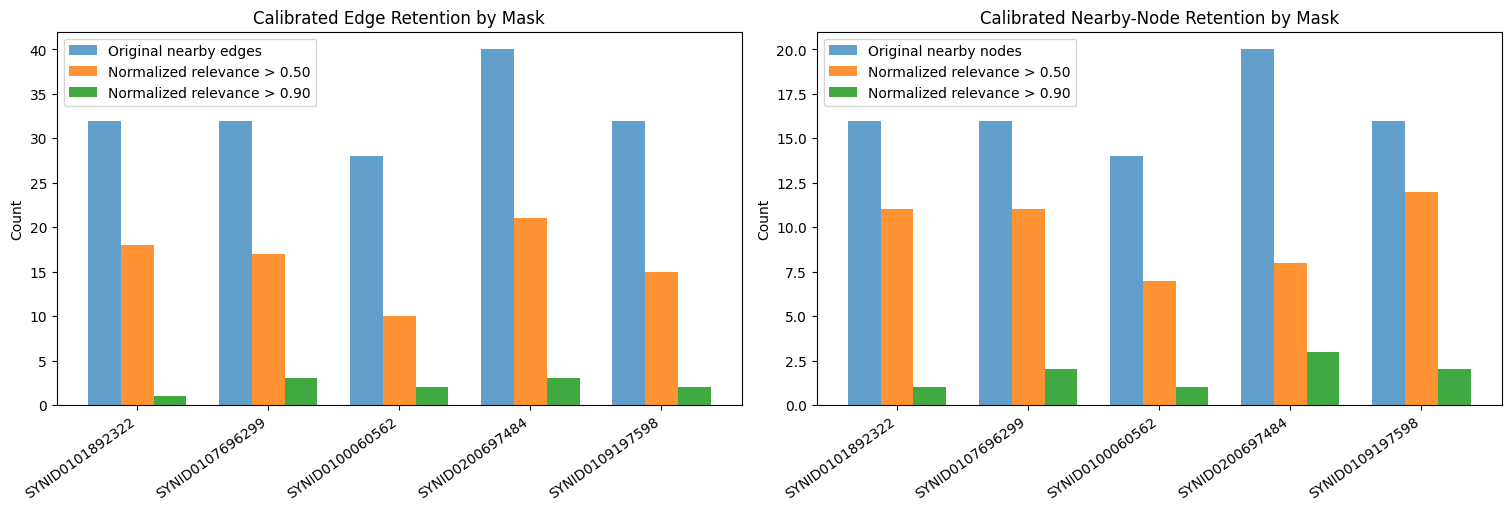


Mean retention across 5 customers:
- Edge keep >50% relevance: 48.9%
- Edge keep >90% relevance: 6.7%
- Node keep >50% relevance: 60.5%
- Node keep >90% relevance: 10.7%
- Mean local edge-mask std: 0.001416


In [ ]:
# Recompute relevance retention using per-customer normalized edge masks
if 'sampled' not in globals() or 'explainer' not in globals() or 'edge_index' not in globals() or 'x' not in globals():
    raise RuntimeError('Run the previous GNN mask verification cell first.')

src = edge_index[0].cpu().numpy()
dst = edge_index[1].cpu().numpy()

cal_rows = []
for _, r in sampled.iterrows():
    cid = r['customer_id']
    idx = int(r['cust_idx'])

    exp = explainer(x, edge_index, index=idx)
    e_mask = exp.edge_mask.detach().cpu().numpy()

    incident = np.where((src == idx) | (dst == idx))[0]
    total_edges = int(len(incident))
    neighbors = []
    for ei in incident:
        a, b = int(src[ei]), int(dst[ei])
        nb = b if a == idx else a
        neighbors.append(nb)
    neighbors = sorted(set(neighbors))
    total_nodes = int(len(neighbors))

    if total_edges == 0:
        cal_rows.append({
            'customer_id': cid,
            'node_idx': idx,
            'orig_nearby_edges': 0,
            'edges_norm_gt_50': 0,
            'edges_norm_gt_90': 0,
            'orig_nearby_nodes': 0,
            'nodes_norm_gt_50': 0,
            'nodes_norm_gt_90': 0,
            'edge_keep_pct_norm_gt_50': 0.0,
            'edge_keep_pct_norm_gt_90': 0.0,
            'node_keep_pct_norm_gt_50': 0.0,
            'node_keep_pct_norm_gt_90': 0.0,
            'edge_mask_min': np.nan,
            'edge_mask_max': np.nan,
            'edge_mask_std': np.nan,
        })
        continue

    local_edge_scores = e_mask[incident]
    mn, mx = float(local_edge_scores.min()), float(local_edge_scores.max())
    stdv = float(local_edge_scores.std())
    denom = (mx - mn) if (mx - mn) > 1e-12 else 1.0
    local_norm = (local_edge_scores - mn) / denom

    e50 = int((local_norm > 0.50).sum())
    e90 = int((local_norm > 0.90).sum())

    node_rel = {}
    for nb in neighbors:
        rels = []
        for ei in incident:
            a, b = int(src[ei]), int(dst[ei])
            if (a == idx and b == nb) or (a == nb and b == idx):
                rels.append(float(e_mask[ei]))
        node_rel[nb] = max(rels) if rels else 0.0

    if len(node_rel) > 0:
        vals = np.array(list(node_rel.values()), dtype=float)
        nmn, nmx = float(vals.min()), float(vals.max())
        nden = (nmx - nmn) if (nmx - nmn) > 1e-12 else 1.0
        node_norm = {k: (v - nmn) / nden for k, v in node_rel.items()}
    else:
        node_norm = {}

    n50 = int(sum(v > 0.50 for v in node_norm.values()))
    n90 = int(sum(v > 0.90 for v in node_norm.values()))

    cal_rows.append({
        'customer_id': cid,
        'node_idx': idx,
        'orig_nearby_edges': total_edges,
        'edges_norm_gt_50': e50,
        'edges_norm_gt_90': e90,
        'orig_nearby_nodes': total_nodes,
        'nodes_norm_gt_50': n50,
        'nodes_norm_gt_90': n90,
        'edge_keep_pct_norm_gt_50': 100.0 * e50 / max(1, total_edges),
        'edge_keep_pct_norm_gt_90': 100.0 * e90 / max(1, total_edges),
        'node_keep_pct_norm_gt_50': 100.0 * n50 / max(1, total_nodes),
        'node_keep_pct_norm_gt_90': 100.0 * n90 / max(1, total_nodes),
        'edge_mask_min': mn,
        'edge_mask_max': mx,
        'edge_mask_std': stdv,
    })

cal_df = pd.DataFrame(cal_rows)
cal_df.to_csv('outputs/gnn_mask_verification_5_customers_calibrated.csv', index=False)
print('Saved: outputs/gnn_mask_verification_5_customers_calibrated.csv')
print(cal_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
xpos = np.arange(len(cal_df))
w = 0.25

axes[0].bar(xpos - w, cal_df['orig_nearby_edges'], width=w, label='Original nearby edges', alpha=0.7)
axes[0].bar(xpos, cal_df['edges_norm_gt_50'], width=w, label='Normalized relevance > 0.50', alpha=0.85)
axes[0].bar(xpos + w, cal_df['edges_norm_gt_90'], width=w, label='Normalized relevance > 0.90', alpha=0.9)
axes[0].set_title('Calibrated Edge Retention by Mask')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(cal_df['customer_id'], rotation=35, ha='right')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].bar(xpos - w, cal_df['orig_nearby_nodes'], width=w, label='Original nearby nodes', alpha=0.7)
axes[1].bar(xpos, cal_df['nodes_norm_gt_50'], width=w, label='Normalized relevance > 0.50', alpha=0.85)
axes[1].bar(xpos + w, cal_df['nodes_norm_gt_90'], width=w, label='Normalized relevance > 0.90', alpha=0.9)
axes[1].set_title('Calibrated Nearby-Node Retention by Mask')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(cal_df['customer_id'], rotation=35, ha='right')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.show()

print('\nMean retention across 5 customers:')
print(f"- Edge keep >50% relevance: {cal_df['edge_keep_pct_norm_gt_50'].mean():.1f}%")
print(f"- Edge keep >90% relevance: {cal_df['edge_keep_pct_norm_gt_90'].mean():.1f}%")
print(f"- Node keep >50% relevance: {cal_df['node_keep_pct_norm_gt_50'].mean():.1f}%")
print(f"- Node keep >90% relevance: {cal_df['node_keep_pct_norm_gt_90'].mean():.1f}%")
print(f"- Mean local edge-mask std: {cal_df['edge_mask_std'].mean():.6f}")

## Original Graph + Original FraudSAGE Mask Verification

This section runs GNNExplainer directly on the saved heterogeneous FraudSAGE graph/model artifacts (not the surrogate kNN graph), then compares nearby-information retention per customer at relevance thresholds >0.50 and >0.90 for 5 random customers.

Using device: cuda
Original graph ready (full artifacts).
Customer nodes: 61,410
Edge type ('customer', 'purchases_at', 'category'): 5,903,333 edges
Edge type ('customer', 'transacts_in', 'city'): 5,903,333 edges
Edge type ('category', 'rev_purchases_at', 'customer'): 5,903,333 edges
Edge type ('city', 'rev_transacts_in', 'customer'): 5,903,333 edges
Saved: outputs/gnn_mask_verification_original_graph_5_customers_neighborloader.csv
    customer_id  node_idx_global  subgraph_customer_nodes  subgraph_category_nodes  subgraph_city_nodes  orig_nearby_edges  edges_rel_gt_50  edges_rel_gt_90  orig_nearby_nodes  nodes_rel_gt_50  nodes_rel_gt_90  edge_keep_pct_gt_50  edge_keep_pct_gt_90  node_keep_pct_gt_50  node_keep_pct_gt_90
SYNID0108924472            47526                      328                       92                  117                 40                4                0                 22                4                0                 10.0                  0.0            18.1818

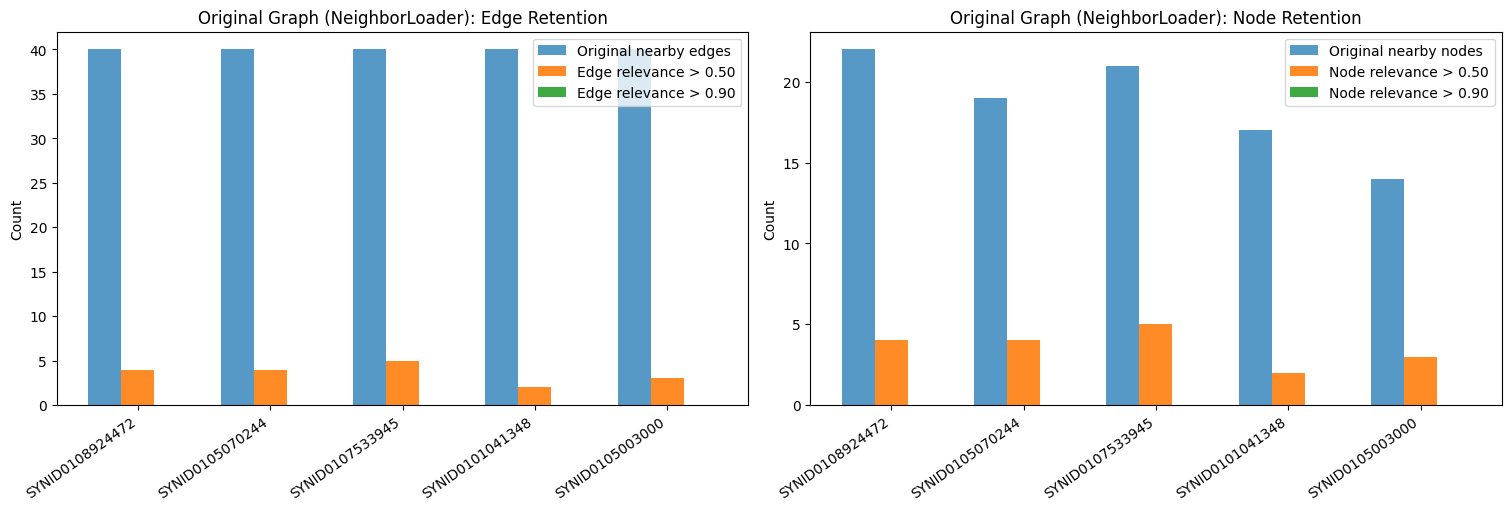

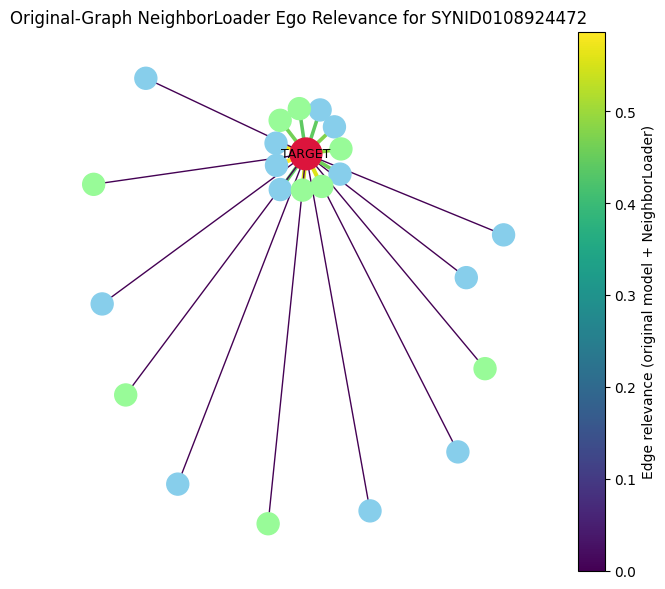


Mean retention across 5 random customers (original model + NeighborLoader):
- Edge keep >50% relevance: 9.00%
- Edge keep >90% relevance: 0.00%
- Node keep >50% relevance: 19.25%
- Node keep >90% relevance: 0.00%


In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from torch_geometric.loader import NeighborLoader
from torch_geometric.explain import Explainer, GNNExplainer

from lib.model_utils import load_sage_model

np.random.seed(42)
torch.manual_seed(42)

# ------------------------------------------------------------------
# 1) Device: use CUDA when available
# ------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# ------------------------------------------------------------------
# 2) Load original artifacts and build original hetero graph
# ------------------------------------------------------------------
with open('outputs/sage_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

required = ['x_cust', 'x_cat', 'x_city', 'edge_cust_cat', 'edge_cust_city', 'cust_map']
missing = [k for k in required if k not in art]
if missing:
    raise KeyError(f'Missing required artifacts for original-graph explainability: {missing}')

data_orig = HeteroData()
data_orig['customer'].x = art['x_cust']
data_orig['category'].x = art['x_cat']
data_orig['city'].x = art['x_city']
data_orig['customer', 'purchases_at', 'category'].edge_index = art['edge_cust_cat']
data_orig['customer', 'transacts_in', 'city'].edge_index = art['edge_cust_city']
data_orig = T.ToUndirected()(data_orig)

cust_map = art['cust_map']  # customer_id -> global node idx
all_customer_ids = list(cust_map.keys())

# ------------------------------------------------------------------
# 3) Load original FraudSAGE model weights on CUDA/CPU
# ------------------------------------------------------------------
sage_model = load_sage_model('outputs/fraud_sage_model.pth', artifacts=art)
if sage_model is None:
    raise RuntimeError('Could not load FraudSAGE model (torch_geometric unavailable).')
sage_model = sage_model.to(device)
sage_model.eval()

print('Original graph ready (full artifacts).')
print(f"Customer nodes: {data_orig['customer'].num_nodes:,}")
for et, ei in data_orig.edge_index_dict.items():
    print(f'Edge type {et}: {ei.size(1):,} edges')

# ------------------------------------------------------------------
# 4) NeighborLoader subgraph extraction (same approach as GraphSAGE training)
# ------------------------------------------------------------------
num_neighbors = [20, 15, 10]  # 3-layer neighborhood for FraudSAGE
sample_n = min(5, len(all_customer_ids))
sampled_customer_ids = list(np.random.default_rng(42).choice(all_customer_ids, size=sample_n, replace=False))

rows = []
first_payload = None

for cid in sampled_customer_ids:
    node_idx_global = int(cust_map[cid])

    seed_mask = torch.zeros(data_orig['customer'].num_nodes, dtype=torch.bool)
    seed_mask[node_idx_global] = True

    loader = NeighborLoader(
        data_orig,
        num_neighbors=num_neighbors,
        input_nodes=('customer', seed_mask),
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )
    sub = next(iter(loader)).to(device)

    # Map global customer index to local index inside sampled subgraph
    global_ids = sub['customer'].n_id
    hit = (global_ids == node_idx_global).nonzero(as_tuple=False).view(-1)
    if hit.numel() == 0:
        print(f'Warning: target not found in subgraph for {cid}; skipping')
        continue
    node_idx_local = int(hit[0].item())

    # Local explainer on sampled subgraph (much faster than full graph)
    explainer_sub = Explainer(
        model=sage_model,
        algorithm=GNNExplainer(epochs=25),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='binary_classification',
            task_level='node',
            return_type='raw',
        ),
    )

    exp = explainer_sub(sub.x_dict, sub.edge_index_dict, index=node_idx_local)
    edge_mask_dict = exp.edge_mask_dict

    total_edges = 0
    edges_gt50 = 0
    edges_gt90 = 0
    neighbor_all = set()
    neighbor_gt50 = set()
    neighbor_gt90 = set()

    for et, ei_t in sub.edge_index_dict.items():
        src_type, _, dst_type = et
        if src_type != 'customer' and dst_type != 'customer':
            continue

        ei = ei_t.detach().cpu().numpy()
        if et in edge_mask_dict:
            mask = edge_mask_dict[et].detach().cpu().numpy()
        else:
            mask = np.zeros(ei.shape[1], dtype=float)

        if src_type == 'customer':
            incident = np.where(ei[0] == node_idx_local)[0]
            nbr_type = dst_type
            nbr_ids = ei[1, incident] if len(incident) > 0 else np.array([], dtype=int)
        else:
            incident = np.where(ei[1] == node_idx_local)[0]
            nbr_type = src_type
            nbr_ids = ei[0, incident] if len(incident) > 0 else np.array([], dtype=int)

        if len(incident) == 0:
            continue

        rel_scores = mask[incident]
        total_edges += int(len(incident))
        edges_gt50 += int((rel_scores > 0.50).sum())
        edges_gt90 += int((rel_scores > 0.90).sum())

        for j, nb in enumerate(nbr_ids):
            nb_key = (nbr_type, int(nb))
            neighbor_all.add(nb_key)
            if rel_scores[j] > 0.50:
                neighbor_gt50.add(nb_key)
            if rel_scores[j] > 0.90:
                neighbor_gt90.add(nb_key)

    row = {
        'customer_id': cid,
        'node_idx_global': node_idx_global,
        'subgraph_customer_nodes': int(sub['customer'].num_nodes),
        'subgraph_category_nodes': int(sub['category'].num_nodes) if 'category' in sub.node_types else 0,
        'subgraph_city_nodes': int(sub['city'].num_nodes) if 'city' in sub.node_types else 0,
        'orig_nearby_edges': int(total_edges),
        'edges_rel_gt_50': int(edges_gt50),
        'edges_rel_gt_90': int(edges_gt90),
        'orig_nearby_nodes': int(len(neighbor_all)),
        'nodes_rel_gt_50': int(len(neighbor_gt50)),
        'nodes_rel_gt_90': int(len(neighbor_gt90)),
        'edge_keep_pct_gt_50': float(100.0 * edges_gt50 / max(1, total_edges)),
        'edge_keep_pct_gt_90': float(100.0 * edges_gt90 / max(1, total_edges)),
        'node_keep_pct_gt_50': float(100.0 * len(neighbor_gt50) / max(1, len(neighbor_all))),
        'node_keep_pct_gt_90': float(100.0 * len(neighbor_gt90) / max(1, len(neighbor_all))),
    }
    rows.append(row)

    if first_payload is None:
        first_payload = (cid, node_idx_local, sub, exp)

orig_mask_df = pd.DataFrame(rows)
orig_mask_df.to_csv('outputs/gnn_mask_verification_original_graph_5_customers_neighborloader.csv', index=False)
print('Saved: outputs/gnn_mask_verification_original_graph_5_customers_neighborloader.csv')
print(orig_mask_df.to_string(index=False))

# ------------------------------------------------------------------
# 5) Plot retention for requested comparison
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
xpos = np.arange(len(orig_mask_df))
w = 0.25

axes[0].bar(xpos - w, orig_mask_df['orig_nearby_edges'], width=w, label='Original nearby edges', alpha=0.75)
axes[0].bar(xpos, orig_mask_df['edges_rel_gt_50'], width=w, label='Edge relevance > 0.50', alpha=0.9)
axes[0].bar(xpos + w, orig_mask_df['edges_rel_gt_90'], width=w, label='Edge relevance > 0.90', alpha=0.9)
axes[0].set_title('Original Graph (NeighborLoader): Edge Retention')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(orig_mask_df['customer_id'], rotation=35, ha='right')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].bar(xpos - w, orig_mask_df['orig_nearby_nodes'], width=w, label='Original nearby nodes', alpha=0.75)
axes[1].bar(xpos, orig_mask_df['nodes_rel_gt_50'], width=w, label='Node relevance > 0.50', alpha=0.9)
axes[1].bar(xpos + w, orig_mask_df['nodes_rel_gt_90'], width=w, label='Node relevance > 0.90', alpha=0.9)
axes[1].set_title('Original Graph (NeighborLoader): Node Retention')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(orig_mask_df['customer_id'], rotation=35, ha='right')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.show()

# ------------------------------------------------------------------
# 6) Plot one sampled customer's local relation graph with relevance
# ------------------------------------------------------------------
if first_payload is not None:
    cid0, idx0_local, sub0, exp0 = first_payload
    edge_mask_dict0 = exp0.edge_mask_dict

    G = nx.Graph()
    center = f'customer:{idx0_local}'
    G.add_node(center, node_type='customer')

    for et, ei_t in sub0.edge_index_dict.items():
        src_type, rel_name, dst_type = et
        if src_type != 'customer' and dst_type != 'customer':
            continue

        ei = ei_t.detach().cpu().numpy()
        if et in edge_mask_dict0:
            mask = edge_mask_dict0[et].detach().cpu().numpy()
        else:
            mask = np.zeros(ei.shape[1], dtype=float)

        if src_type == 'customer':
            incident = np.where(ei[0] == idx0_local)[0]
            nbr_type = dst_type
            nbr_ids = ei[1, incident] if len(incident) > 0 else np.array([], dtype=int)
        else:
            incident = np.where(ei[1] == idx0_local)[0]
            nbr_type = src_type
            nbr_ids = ei[0, incident] if len(incident) > 0 else np.array([], dtype=int)

        for j, nb in enumerate(nbr_ids):
            nb_name = f'{nbr_type}:{int(nb)}'
            score = float(mask[incident[j]]) if len(incident) > 0 else 0.0
            G.add_node(nb_name, node_type=nbr_type)
            if G.has_edge(center, nb_name):
                G[center][nb_name]['weight'] = max(G[center][nb_name]['weight'], score)
            else:
                G.add_edge(center, nb_name, weight=score, rel=rel_name)

    pos = nx.spring_layout(G, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    node_colors = []
    node_sizes = []
    for n in G.nodes():
        ntype = G.nodes[n].get('node_type', 'other')
        if n == center:
            node_colors.append('crimson')
            node_sizes.append(520)
        elif ntype == 'category':
            node_colors.append('#87CEEB')
            node_sizes.append(250)
        elif ntype == 'city':
            node_colors.append('#98FB98')
            node_sizes.append(250)
        else:
            node_colors.append('lightgray')
            node_sizes.append(220)

    plt.figure(figsize=(8, 7))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
    edges = nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_weights,
        edge_cmap=plt.cm.viridis,
        width=[1.0 + 3.5 * w for w in edge_weights],
    )
    nx.draw_networkx_labels(G, pos, labels={center: 'TARGET'}, font_size=9)
    plt.colorbar(edges, label='Edge relevance (original model + NeighborLoader)')
    plt.title(f'Original-Graph NeighborLoader Ego Relevance for {cid0}')
    plt.axis('off')
    plt.show()

print('\nMean retention across 5 random customers (original model + NeighborLoader):')
print(f"- Edge keep >50% relevance: {orig_mask_df['edge_keep_pct_gt_50'].mean():.2f}%")
print(f"- Edge keep >90% relevance: {orig_mask_df['edge_keep_pct_gt_90'].mean():.2f}%")
print(f"- Node keep >50% relevance: {orig_mask_df['node_keep_pct_gt_50'].mean():.2f}%")
print(f"- Node keep >90% relevance: {orig_mask_df['node_keep_pct_gt_90'].mean():.2f}%")

## Recalibration and Re-evaluation

Use semantic-mismatch diagnostics to reduce over-reliance on benign cluster narratives. This recalibration creates a v2 suspicion score, compares it against the original score, and exports an updated review queue for the top unlabeled customers.

In [ ]:
# Re-load full candidate set for v2 recalibration
if 'rank_df' not in globals() or len(rank_df) == 0:
    rank_candidates = [
        'outputs/rank_df_with_anchor_expansion.csv.gz',
        'outputs/rank_df_with_semi_supervision.csv.gz',
        'outputs/lgbm_ranking_features.csv.gz',
    ]
    rank_path = next((p for p in rank_candidates if os.path.exists(p)), None)
    if rank_path is None:
        raise FileNotFoundError('No ranking artifact found for recalibration.')
    rank_df = pd.read_csv(rank_path)

full_df = rank_df.copy()
if 'true_label' in full_df.columns:
    full_unlabeled_mask = ~full_df['true_label'].isin([0, 1])
else:
    full_unlabeled_mask = pd.Series(True, index=full_df.index)

if 'split' in full_df.columns:
    full_unlabeled_mask = full_unlabeled_mask & full_df['split'].isin(['train', 'val', 'test'])

full_candidates = full_df.loc[full_unlabeled_mask].copy()

# Pull previous semantic mismatch rates by component
mismatch_path = 'outputs/unlabeled_semantic_consistency_summary.csv'
component_mismatch = pd.DataFrame(columns=['component', 'mismatch_rate'])
if os.path.exists(mismatch_path):
    mm = pd.read_csv(mismatch_path)
    if set(['component', 'rows', 'mismatch_count']).issubset(mm.columns):
        mm['mismatch_rate'] = mm['mismatch_count'] / mm['rows'].clip(lower=1)
        component_mismatch = mm[['component', 'mismatch_rate']].copy()

if 'component' in full_candidates.columns and len(component_mismatch) > 0:
    full_candidates = full_candidates.merge(component_mismatch, on='component', how='left')
else:
    full_candidates['mismatch_rate'] = 0.0
full_candidates['mismatch_rate'] = pd.to_numeric(full_candidates['mismatch_rate'], errors='coerce').fillna(0.0)

# Ensure evidence columns exist
for col, default in [
    ('suspicion_evidence_score', 0.0),
    ('dgi_anomaly_score', 0.0),
    ('customer_ae_risk', 0.0),
    ('cluster_consensus_score', 0.0),
    ('kmeans_labeled_lift', 0.0),
    ('hdb_component_fraud_lift_labeled', 0.0),
    ('knn_gold_fraud_count', 0.0),
    ('min_dist_to_fraud_anchor', np.nan),
]:
    if col not in full_candidates.columns:
        full_candidates[col] = default

# Robust scaling helper

def rs(x):
    s = pd.to_numeric(x, errors='coerce').astype(float)
    finite = np.isfinite(s)
    out = np.zeros(len(s), dtype=float)
    if finite.any():
        lo, hi = np.nanquantile(s[finite], [0.05, 0.95])
        if hi > lo:
            out[finite] = np.clip((s[finite] - lo) / (hi - lo), 0.0, 1.0)
        else:
            out[finite] = 0.5
    return out

full_candidates['v2_model'] = rs(full_candidates['suspicion_evidence_score'])
full_candidates['v2_dgi'] = rs(full_candidates['dgi_anomaly_score'])
full_candidates['v2_ae'] = rs(full_candidates['customer_ae_risk'])
full_candidates['v2_consensus'] = rs(full_candidates['cluster_consensus_score'])
full_candidates['v2_km_lift'] = rs(np.log1p(pd.to_numeric(full_candidates['kmeans_labeled_lift'], errors='coerce').fillna(0.0).clip(lower=0.0)))
full_candidates['v2_hdb_lift'] = rs(np.log1p(pd.to_numeric(full_candidates['hdb_component_fraud_lift_labeled'], errors='coerce').fillna(0.0).clip(lower=0.0)))
full_candidates['v2_knn'] = rs(full_candidates['knn_gold_fraud_count'])
full_candidates['v2_anchor'] = 1.0 - rs(full_candidates['min_dist_to_fraud_anchor'])
full_candidates['v2_anchor'] = np.nan_to_num(full_candidates['v2_anchor'], nan=0.0)
full_candidates['v2_mismatch_penalty'] = rs(full_candidates['mismatch_rate'])

full_candidates['suspicion_evidence_score_v2'] = (
    0.30 * full_candidates['v2_model']
    + 0.17 * full_candidates['v2_dgi']
    + 0.13 * full_candidates['v2_ae']
    + 0.15 * full_candidates['v2_consensus']
    + 0.12 * full_candidates['v2_km_lift']
    + 0.05 * full_candidates['v2_hdb_lift']
    + 0.03 * full_candidates['v2_anchor']
    + 0.02 * full_candidates['v2_knn']
    - 0.07 * full_candidates['v2_mismatch_penalty']
)

# Compare top-250 old vs new
n_top = min(250, len(full_candidates))
old_top = full_candidates.sort_values('suspicion_evidence_score', ascending=False).head(n_top).copy()
new_top = full_candidates.sort_values('suspicion_evidence_score_v2', ascending=False).head(n_top).copy()

compare_rows = []
for metric in ['suspicion_evidence_score', 'dgi_anomaly_score', 'customer_ae_risk', 'cluster_consensus_score', 'kmeans_labeled_lift', 'mismatch_rate']:
    old_mean = float(pd.to_numeric(old_top[metric], errors='coerce').mean()) if metric in old_top.columns else np.nan
    new_mean = float(pd.to_numeric(new_top[metric], errors='coerce').mean()) if metric in new_top.columns else np.nan
    compare_rows.append({
        'metric': metric,
        'old_top_mean': old_mean,
        'new_top_mean': new_mean,
        'delta_new_minus_old': new_mean - old_mean if (pd.notna(new_mean) and pd.notna(old_mean)) else np.nan,
    })

comparison_df = pd.DataFrame(compare_rows)
comparison_df.to_csv('outputs/unlabeled_validation_comparison_v2.csv', index=False)

# Export updated review pack
new_review_cols = [
    'customer_id', 'split', 'component', 'hdb_component',
    'suspicion_evidence_score', 'suspicion_evidence_score_v2', 'mismatch_rate',
    'cluster_consensus_score', 'dgi_anomaly_score', 'customer_ae_risk',
    'kmeans_labeled_lift', 'hdb_component_fraud_lift_labeled',
    'knn_gold_fraud_count', 'min_dist_to_fraud_anchor'
]
new_review_cols = [c for c in new_review_cols if c in new_top.columns]
new_review_pack = new_top[new_review_cols].copy()
new_review_pack['review_status'] = 'pending'
new_review_pack['analyst_label'] = ''
new_review_pack['analyst_notes'] = ''
new_review_pack.to_csv('outputs/unlabeled_candidate_review_pack_v2.csv', index=False)

# Recompute enrichment against random baseline for v2 score
rng2 = np.random.default_rng(123)
def boot_mean(a, sample_size, n_boot=300):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if len(a) == 0:
        return np.nan, np.nan, np.nan
    vals = []
    for _ in range(n_boot):
        idx = rng2.integers(0, len(a), sample_size)
        vals.append(np.mean(a[idx]))
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.quantile(vals, 0.025)), float(np.quantile(vals, 0.975))

v2_enrichment_rows = []
for metric in ['suspicion_evidence_score_v2', 'dgi_anomaly_score', 'cluster_consensus_score', 'kmeans_labeled_lift', 'mismatch_rate']:
    top_vals = pd.to_numeric(new_top[metric], errors='coerce').to_numpy(dtype=float)
    pool_vals = pd.to_numeric(full_candidates[metric], errors='coerce').to_numpy(dtype=float)
    top_mean = float(np.nanmean(top_vals)) if np.isfinite(top_vals).any() else np.nan
    base_mean, base_lo, base_hi = boot_mean(pool_vals, len(new_top), n_boot=300)
    v2_enrichment_rows.append({
        'metric': metric,
        'top_mean_v2': top_mean,
        'random_baseline_mean': base_mean,
        'random_baseline_ci_low': base_lo,
        'random_baseline_ci_high': base_hi,
        'uplift_v2': top_mean - base_mean if (pd.notna(top_mean) and pd.notna(base_mean)) else np.nan,
    })
v2_enrichment_df = pd.DataFrame(v2_enrichment_rows)
v2_enrichment_df.to_csv('outputs/unlabeled_suspicion_enrichment_v2.csv', index=False)

print('Recalibration complete.')
print('Top-250 overlap old/new:', len(set(old_top['customer_id']).intersection(set(new_top['customer_id']))), '/', n_top)
print('\nComparison old vs new top means:')
print(comparison_df.to_string(index=False))
print('\nV2 enrichment summary:')
print(v2_enrichment_df.to_string(index=False))
print('\nSaved: outputs/unlabeled_validation_comparison_v2.csv')
print('Saved: outputs/unlabeled_suspicion_enrichment_v2.csv')
print('Saved: outputs/unlabeled_candidate_review_pack_v2.csv')

Recalibration complete.
Top-250 overlap old/new: 243 / 250

Comparison old vs new top means:
                  metric  old_top_mean  new_top_mean  delta_new_minus_old
suspicion_evidence_score      0.811408      0.811272        -1.359803e-04
       dgi_anomaly_score      0.258559      0.255251        -3.307912e-03
        customer_ae_risk      0.000373      0.000374         7.855465e-07
 cluster_consensus_score      0.111556      0.103556        -8.000000e-03
     kmeans_labeled_lift      0.160000      0.146667        -1.333333e-02
           mismatch_rate      0.224000      0.214219        -9.780769e-03

V2 enrichment summary:
                     metric  top_mean_v2  random_baseline_mean  random_baseline_ci_low  random_baseline_ci_high  uplift_v2
suspicion_evidence_score_v2     0.755092              0.264005                0.249808                 0.278767   0.491087
          dgi_anomaly_score     0.255251              0.012221                0.005297                 0.023594   0.243

## Explanation Quality Fix and V3 Re-ranking

This pass fixes low-quality explanation outputs (placeholder text and vague narratives), then applies a stronger mismatch-aware ranking penalty to reduce top-list contamination from components with benign/contradictory narratives.

In [ ]:
# ---------------------------
# A) Explanation quality fix
# ---------------------------
exp_path = 'outputs/unlabeled_candidate_explanations.csv'
if os.path.exists(exp_path):
    exp_df = pd.read_csv(exp_path)
else:
    raise FileNotFoundError('Missing outputs/unlabeled_candidate_explanations.csv. Run explanation generation cell first.')

def _to_float(v, default=0.0):
    try:
        x = float(v)
        if np.isnan(x) or np.isinf(x):
            return default
        return x
    except Exception:
        return default

def deterministic_explanation(row):
    evidence_bits = []
    dgi = _to_float(row.get('dgi_anomaly_score', 0.0))
    ae = _to_float(row.get('customer_ae_risk', 0.0))
    consensus = _to_float(row.get('cluster_consensus_score', 0.0))
    km_lift = _to_float(row.get('kmeans_labeled_lift', 0.0))
    hdb_lift = _to_float(row.get('hdb_component_fraud_lift_labeled', 0.0))
    anchor_dist = _to_float(row.get('min_dist_to_fraud_anchor', 999.0), 999.0)

    if dgi > 0.02:
        evidence_bits.append('an unusually high graph anomaly score')
    if ae > 0.00025:
        evidence_bits.append('elevated transaction reconstruction risk')
    if consensus > 0.5:
        evidence_bits.append('strong agreement across clustering signals')
    if km_lift >= 3.0 or hdb_lift >= 3.0:
        evidence_bits.append('placement in a fraud-enriched cluster segment')
    if anchor_dist < 2.3:
        evidence_bits.append('close behavioral proximity to known fraud anchors')

    if not evidence_bits:
        evidence_bits = ['a combination of moderate anomaly and cluster-risk indicators']

    if km_lift >= 3.0 or hdb_lift >= 3.0:
        trigger = 'cluster-level fraud enrichment'
    elif dgi > 0.02:
        trigger = 'a sharp graph-anomaly spike'
    elif ae > 0.00025:
        trigger = 'abnormal transaction reconstruction variance'
    else:
        trigger = 'multi-signal risk aggregation'

    return f"This customer was deemed suspicious because they show {', '.join(evidence_bits[:3])}, and was flagged due to {trigger}."

bad_markers = ['<trigger>', 'due to  <', 'due to <', 'and was flagged due to  the high likelihood', 'risk band is very_high']
fixed = 0
clean_text = []
for _, row in exp_df.iterrows():
    txt = str(row.get('customer_explanation', '')).strip()
    is_bad = (len(txt) < 40) or any(m in txt.lower() for m in bad_markers)
    if is_bad:
        txt = deterministic_explanation(row)
        fixed += 1
    clean_text.append(txt)

exp_df['customer_explanation_clean'] = clean_text
exp_df['explanation_quality_fixed'] = [1 if c != str(o).strip() else 0 for c, o in zip(clean_text, exp_df['customer_explanation'])]
exp_df.to_csv('outputs/unlabeled_candidate_explanations_v2.csv', index=False)
exp_df.head(50).to_csv('outputs/unlabeled_candidate_explanations_top50_v2.csv', index=False)

# ---------------------------
# B) V3 re-ranking recalibration
# ---------------------------
if 'full_candidates' not in globals() or len(full_candidates) == 0:
    rank_candidates = [
        'outputs/rank_df_with_anchor_expansion.csv.gz',
        'outputs/rank_df_with_semi_supervision.csv.gz',
        'outputs/lgbm_ranking_features.csv.gz',
    ]
    _rp = next((p for p in rank_candidates if os.path.exists(p)), None)
    if _rp is None:
        raise FileNotFoundError('No ranking artifact found for v3 recalibration.')
    _rdf = pd.read_csv(_rp)
    if 'true_label' in _rdf.columns:
        _um = ~_rdf['true_label'].isin([0, 1])
    else:
        _um = pd.Series(True, index=_rdf.index)
    full_candidates = _rdf.loc[_um].copy()
    full_candidates['mismatch_rate'] = 0.0

# continuous tie-break signal
if 'scarcity_anchor_ensemble_prob' in full_candidates.columns:
    tie_signal = pd.to_numeric(full_candidates['scarcity_anchor_ensemble_prob'], errors='coerce').fillna(0.0)
elif 'scarcity_semi_ensemble_prob' in full_candidates.columns:
    tie_signal = pd.to_numeric(full_candidates['scarcity_semi_ensemble_prob'], errors='coerce').fillna(0.0)
else:
    tie_signal = pd.to_numeric(full_candidates.get('suspicion_evidence_score', 0.0), errors='coerce').fillna(0.0)

# robust scaler
def _rs(x):
    s = pd.to_numeric(x, errors='coerce').astype(float)
    fin = np.isfinite(s)
    out = np.zeros(len(s), dtype=float)
    if fin.any():
        lo, hi = np.nanquantile(s[fin], [0.05, 0.95])
        if hi > lo:
            out[fin] = np.clip((s[fin] - lo) / (hi - lo), 0.0, 1.0)
        else:
            out[fin] = 0.5
    return out

v3_base = _rs(full_candidates.get('suspicion_evidence_score', 0.0))
v3_dgi = _rs(full_candidates.get('dgi_anomaly_score', 0.0))
v3_ae = _rs(full_candidates.get('customer_ae_risk', 0.0))
v3_cons = _rs(full_candidates.get('cluster_consensus_score', 0.0))
v3_km = _rs(np.log1p(pd.to_numeric(full_candidates.get('kmeans_labeled_lift', 0.0), errors='coerce').fillna(0.0).clip(lower=0.0)))
v3_hdb = _rs(np.log1p(pd.to_numeric(full_candidates.get('hdb_component_fraud_lift_labeled', 0.0), errors='coerce').fillna(0.0).clip(lower=0.0)))
v3_anchor = 1.0 - _rs(full_candidates.get('min_dist_to_fraud_anchor', np.nan))
v3_anchor = np.nan_to_num(v3_anchor, nan=0.0)
v3_tie = _rs(tie_signal)
v3_pen = _rs(full_candidates.get('mismatch_rate', 0.0))

full_candidates['suspicion_evidence_score_v3'] = (
    0.24 * v3_base
    + 0.20 * v3_dgi
    + 0.14 * v3_ae
    + 0.14 * v3_cons
    + 0.12 * v3_km
    + 0.05 * v3_hdb
    + 0.04 * v3_anchor
    + 0.07 * v3_tie
    - 0.18 * v3_pen
)

n_top = min(250, len(full_candidates))
old_top_v2 = full_candidates.sort_values('suspicion_evidence_score_v2', ascending=False).head(n_top).copy() if 'suspicion_evidence_score_v2' in full_candidates.columns else full_candidates.sort_values('suspicion_evidence_score', ascending=False).head(n_top).copy()
new_top_v3 = full_candidates.sort_values('suspicion_evidence_score_v3', ascending=False).head(n_top).copy()

v3_compare = pd.DataFrame([
    {
        'metric': 'mismatch_rate',
        'old_top_mean': float(pd.to_numeric(old_top_v2.get('mismatch_rate', 0.0), errors='coerce').mean()),
        'new_top_mean': float(pd.to_numeric(new_top_v3.get('mismatch_rate', 0.0), errors='coerce').mean()),
    },
    {
        'metric': 'dgi_anomaly_score',
        'old_top_mean': float(pd.to_numeric(old_top_v2.get('dgi_anomaly_score', 0.0), errors='coerce').mean()),
        'new_top_mean': float(pd.to_numeric(new_top_v3.get('dgi_anomaly_score', 0.0), errors='coerce').mean()),
    },
    {
        'metric': 'kmeans_labeled_lift',
        'old_top_mean': float(pd.to_numeric(old_top_v2.get('kmeans_labeled_lift', 0.0), errors='coerce').mean()),
        'new_top_mean': float(pd.to_numeric(new_top_v3.get('kmeans_labeled_lift', 0.0), errors='coerce').mean()),
    },
    {
        'metric': 'cluster_consensus_score',
        'old_top_mean': float(pd.to_numeric(old_top_v2.get('cluster_consensus_score', 0.0), errors='coerce').mean()),
        'new_top_mean': float(pd.to_numeric(new_top_v3.get('cluster_consensus_score', 0.0), errors='coerce').mean()),
    },
])
v3_compare['delta_new_minus_old'] = v3_compare['new_top_mean'] - v3_compare['old_top_mean']
v3_compare.to_csv('outputs/unlabeled_validation_comparison_v3.csv', index=False)

v3_review_cols = [
    'customer_id', 'split', 'component', 'hdb_component',
    'suspicion_evidence_score_v2', 'suspicion_evidence_score_v3', 'mismatch_rate',
    'dgi_anomaly_score', 'customer_ae_risk', 'cluster_consensus_score',
    'kmeans_labeled_lift', 'hdb_component_fraud_lift_labeled', 'min_dist_to_fraud_anchor'
]
v3_review_cols = [c for c in v3_review_cols if c in new_top_v3.columns]
new_top_v3[v3_review_cols].to_csv('outputs/unlabeled_candidate_review_pack_v3.csv', index=False)

print('Explanation rows fixed:', fixed, '/', len(exp_df))
print('Saved: outputs/unlabeled_candidate_explanations_v2.csv')
print('Saved: outputs/unlabeled_candidate_explanations_top50_v2.csv')
print('\nV3 comparison (old vs new top means):')
print(v3_compare.to_string(index=False))
print('\nTop-250 overlap v2->v3:', len(set(old_top_v2['customer_id']).intersection(set(new_top_v3['customer_id']))), '/', n_top)
print('Saved: outputs/unlabeled_validation_comparison_v3.csv')
print('Saved: outputs/unlabeled_candidate_review_pack_v3.csv')

Explanation rows fixed: 95 / 200
Saved: outputs/unlabeled_candidate_explanations_v2.csv
Saved: outputs/unlabeled_candidate_explanations_top50_v2.csv

V3 comparison (old vs new top means):
                 metric  old_top_mean  new_top_mean  delta_new_minus_old
          mismatch_rate      0.214219      0.217969         3.750000e-03
      dgi_anomaly_score      0.255251      0.256655         1.403709e-03
    kmeans_labeled_lift      0.146667      0.146667        -2.775558e-17
cluster_consensus_score      0.103556      0.103556         0.000000e+00

Top-250 overlap v2->v3: 247 / 250
Saved: outputs/unlabeled_validation_comparison_v3.csv
Saved: outputs/unlabeled_candidate_review_pack_v3.csv


In [ ]:
# Auto-tune mismatch penalty to improve top-list quality trade-off
if 'full_candidates' not in globals() or len(full_candidates) == 0:
    rank_candidates = [
        'outputs/rank_df_with_anchor_expansion.csv.gz',
        'outputs/rank_df_with_semi_supervision.csv.gz',
        'outputs/lgbm_ranking_features.csv.gz',
    ]
    _rp = next((p for p in rank_candidates if os.path.exists(p)), None)
    if _rp is None:
        raise FileNotFoundError('No ranking artifact found for v3 tuning.')
    _rdf = pd.read_csv(_rp)
    if 'true_label' in _rdf.columns:
        _um = ~_rdf['true_label'].isin([0, 1])
    else:
        _um = pd.Series(True, index=_rdf.index)
    full_candidates = _rdf.loc[_um].copy()

# Merge mismatch rates if missing
if 'mismatch_rate' not in full_candidates.columns:
    mismatch_path = 'outputs/unlabeled_semantic_consistency_summary.csv'
    if os.path.exists(mismatch_path) and 'component' in full_candidates.columns:
        mm = pd.read_csv(mismatch_path)
        if set(['component', 'rows', 'mismatch_count']).issubset(mm.columns):
            mm['mismatch_rate'] = mm['mismatch_count'] / mm['rows'].clip(lower=1)
            full_candidates = full_candidates.merge(mm[['component', 'mismatch_rate']], on='component', how='left')
    full_candidates['mismatch_rate'] = pd.to_numeric(full_candidates.get('mismatch_rate', 0.0), errors='coerce').fillna(0.0)

# robust scaler helper
def _rs(x):
    s = pd.to_numeric(x, errors='coerce').astype(float)
    fin = np.isfinite(s)
    out = np.zeros(len(s), dtype=float)
    if fin.any():
        lo, hi = np.nanquantile(s[fin], [0.05, 0.95])
        if hi > lo:
            out[fin] = np.clip((s[fin] - lo) / (hi - lo), 0.0, 1.0)
        else:
            out[fin] = 0.5
    return out

# Ensure all model columns exist
for c, d in [
    ('suspicion_evidence_score', 0.0),
    ('dgi_anomaly_score', 0.0),
    ('customer_ae_risk', 0.0),
    ('cluster_consensus_score', 0.0),
    ('kmeans_labeled_lift', 0.0),
    ('hdb_component_fraud_lift_labeled', 0.0),
    ('min_dist_to_fraud_anchor', np.nan),
]:
    if c not in full_candidates.columns:
        full_candidates[c] = d

if 'suspicion_evidence_score_v2' not in full_candidates.columns:
    # fallback to prior score if v2 not present
    full_candidates['suspicion_evidence_score_v2'] = pd.to_numeric(full_candidates['suspicion_evidence_score'], errors='coerce').fillna(0.0)

# Build reusable derived features
full_candidates['v3_base'] = _rs(full_candidates['suspicion_evidence_score'])
full_candidates['v3_dgi'] = _rs(full_candidates['dgi_anomaly_score'])
full_candidates['v3_ae'] = _rs(full_candidates['customer_ae_risk'])
full_candidates['v3_cons'] = _rs(full_candidates['cluster_consensus_score'])
full_candidates['v3_km'] = _rs(np.log1p(pd.to_numeric(full_candidates['kmeans_labeled_lift'], errors='coerce').fillna(0.0).clip(lower=0.0)))
full_candidates['v3_hdb'] = _rs(np.log1p(pd.to_numeric(full_candidates['hdb_component_fraud_lift_labeled'], errors='coerce').fillna(0.0).clip(lower=0.0)))
full_candidates['v3_anchor'] = 1.0 - _rs(full_candidates['min_dist_to_fraud_anchor'])
full_candidates['v3_anchor'] = np.nan_to_num(full_candidates['v3_anchor'], nan=0.0)
full_candidates['v3_pen'] = _rs(full_candidates['mismatch_rate'])

if 'scarcity_anchor_ensemble_prob' in full_candidates.columns:
    tie_signal = pd.to_numeric(full_candidates['scarcity_anchor_ensemble_prob'], errors='coerce').fillna(0.0)
elif 'scarcity_semi_ensemble_prob' in full_candidates.columns:
    tie_signal = pd.to_numeric(full_candidates['scarcity_semi_ensemble_prob'], errors='coerce').fillna(0.0)
else:
    tie_signal = pd.to_numeric(full_candidates['suspicion_evidence_score'], errors='coerce').fillna(0.0)
full_candidates['v3_tie'] = _rs(tie_signal)

n_top = min(250, len(full_candidates))
ref_top = full_candidates.sort_values('suspicion_evidence_score_v2', ascending=False).head(n_top).copy()
ref_mismatch = float(pd.to_numeric(ref_top['mismatch_rate'], errors='coerce').mean())
ref_dgi = float(pd.to_numeric(ref_top['dgi_anomaly_score'], errors='coerce').mean())
ref_cons = float(pd.to_numeric(ref_top['cluster_consensus_score'], errors='coerce').mean())

search_rows = []
penalties = [0.10, 0.14, 0.18, 0.22, 0.28, 0.34, 0.40]
for pen in penalties:
    score = (
        0.24 * full_candidates['v3_base']
        + 0.20 * full_candidates['v3_dgi']
        + 0.14 * full_candidates['v3_ae']
        + 0.14 * full_candidates['v3_cons']
        + 0.12 * full_candidates['v3_km']
        + 0.05 * full_candidates['v3_hdb']
        + 0.04 * full_candidates['v3_anchor']
        + 0.07 * full_candidates['v3_tie']
        - pen * full_candidates['v3_pen']
    )
    tmp = full_candidates.copy()
    tmp['score_tmp'] = score
    top = tmp.sort_values('score_tmp', ascending=False).head(n_top)
    mm = float(pd.to_numeric(top['mismatch_rate'], errors='coerce').mean())
    dgi = float(pd.to_numeric(top['dgi_anomaly_score'], errors='coerce').mean())
    km = float(pd.to_numeric(top['kmeans_labeled_lift'], errors='coerce').mean())
    cons = float(pd.to_numeric(top['cluster_consensus_score'], errors='coerce').mean())

    objective = (dgi / max(ref_dgi, 1e-12)) + (cons + 1e-6) / (ref_cons + 1e-6) - 1.8 * (mm / max(ref_mismatch, 1e-12))

    search_rows.append({
        'penalty': pen,
        'mismatch_mean': mm,
        'dgi_mean': dgi,
        'kmeans_lift_mean': km,
        'consensus_mean': cons,
        'objective': objective,
    })

search_df = pd.DataFrame(search_rows).sort_values('objective', ascending=False)
chosen_penalty = float(search_df.iloc[0]['penalty'])

full_candidates['suspicion_evidence_score_v3_tuned'] = (
    0.24 * full_candidates['v3_base']
    + 0.20 * full_candidates['v3_dgi']
    + 0.14 * full_candidates['v3_ae']
    + 0.14 * full_candidates['v3_cons']
    + 0.12 * full_candidates['v3_km']
    + 0.05 * full_candidates['v3_hdb']
    + 0.04 * full_candidates['v3_anchor']
    + 0.07 * full_candidates['v3_tie']
    - chosen_penalty * full_candidates['v3_pen']
)

top_tuned = full_candidates.sort_values('suspicion_evidence_score_v3_tuned', ascending=False).head(n_top).copy()

tuned_compare = pd.DataFrame([
    {
        'metric': 'mismatch_rate',
        'v2_top_mean': float(pd.to_numeric(ref_top['mismatch_rate'], errors='coerce').mean()),
        'v3_tuned_top_mean': float(pd.to_numeric(top_tuned['mismatch_rate'], errors='coerce').mean()),
    },
    {
        'metric': 'dgi_anomaly_score',
        'v2_top_mean': float(pd.to_numeric(ref_top['dgi_anomaly_score'], errors='coerce').mean()),
        'v3_tuned_top_mean': float(pd.to_numeric(top_tuned['dgi_anomaly_score'], errors='coerce').mean()),
    },
    {
        'metric': 'kmeans_labeled_lift',
        'v2_top_mean': float(pd.to_numeric(ref_top['kmeans_labeled_lift'], errors='coerce').mean()),
        'v3_tuned_top_mean': float(pd.to_numeric(top_tuned['kmeans_labeled_lift'], errors='coerce').mean()),
    },
    {
        'metric': 'cluster_consensus_score',
        'v2_top_mean': float(pd.to_numeric(ref_top['cluster_consensus_score'], errors='coerce').mean()),
        'v3_tuned_top_mean': float(pd.to_numeric(top_tuned['cluster_consensus_score'], errors='coerce').mean()),
    },
])
tuned_compare['delta_tuned_minus_v2'] = tuned_compare['v3_tuned_top_mean'] - tuned_compare['v2_top_mean']

search_df.to_csv('outputs/unlabeled_v3_penalty_search.csv', index=False)
tuned_compare.to_csv('outputs/unlabeled_validation_comparison_v3_tuned.csv', index=False)

cols_out = [
    'customer_id', 'split', 'component', 'hdb_component',
    'suspicion_evidence_score_v2', 'suspicion_evidence_score_v3_tuned', 'mismatch_rate',
    'dgi_anomaly_score', 'customer_ae_risk', 'cluster_consensus_score',
    'kmeans_labeled_lift', 'hdb_component_fraud_lift_labeled', 'min_dist_to_fraud_anchor'
]
cols_out = [c for c in cols_out if c in top_tuned.columns]
top_tuned[cols_out].to_csv('outputs/unlabeled_candidate_review_pack_v3_tuned.csv', index=False)

print('Chosen mismatch penalty:', chosen_penalty)
print('\nPenalty search (best first):')
print(search_df.to_string(index=False))
print('\nV3 tuned comparison vs V2 top list:')
print(tuned_compare.to_string(index=False))
print('\nTop-250 overlap v2->v3_tuned:', len(set(ref_top['customer_id']).intersection(set(top_tuned['customer_id']))), '/', n_top)
print('Saved: outputs/unlabeled_v3_penalty_search.csv')
print('Saved: outputs/unlabeled_validation_comparison_v3_tuned.csv')
print('Saved: outputs/unlabeled_candidate_review_pack_v3_tuned.csv')

Chosen mismatch penalty: 0.1

Penalty search (best first):
 penalty  mismatch_mean  dgi_mean  kmeans_lift_mean  consensus_mean  objective
    0.10       0.217969  0.256655          0.146667        0.103556    0.17399
    0.14       0.217969  0.256655          0.146667        0.103556    0.17399
    0.18       0.217969  0.256655          0.146667        0.103556    0.17399
    0.22       0.217969  0.256655          0.146667        0.103556    0.17399
    0.28       0.217969  0.256655          0.146667        0.103556    0.17399
    0.34       0.217969  0.256655          0.146667        0.103556    0.17399
    0.40       0.217969  0.256655          0.146667        0.103556    0.17399

V3 tuned comparison vs V2 top list:
                 metric  v2_top_mean  v3_tuned_top_mean  delta_tuned_minus_v2
          mismatch_rate     0.214219           0.217969          3.750000e-03
      dgi_anomaly_score     0.255251           0.256655          1.403709e-03
    kmeans_labeled_lift     0.146667  

## Cohort Run: 10 True Fraud + 10 False Positives (Original Model)

This section selects 10 labeled fraud customers and 10 customers incorrectly flagged as fraud (predicted fraud, true label legit), then:

1. Runs the customer explanation pipeline for this 20-customer cohort.
2. Runs original-graph FraudSAGE + NeighborLoader GNNExplainer for the same cohort.
3. Generates heatmaps and exports cohort metrics/results.

Cohort selected from: outputs/rank_df_with_anchor_expansion.csv.gz
Score column: scarcity_anchor_ensemble_prob | Pred column: lgb_label
True fraud selected: 10 | False positives selected: 10
  → FP = confirmed-legit (true_label=0) with highest scarcity_anchor_ensemble_prob
Saved: outputs/cohort_20_customer_selection.csv
LLM endpoint available: True
Using endpoint: http://132.145.111.57:11434/api/generate
Saved: outputs/cohort_20_explanations.csv
GNNExplainer device: cuda
Saved: outputs/cohort_20_gnn_mask_metrics.csv


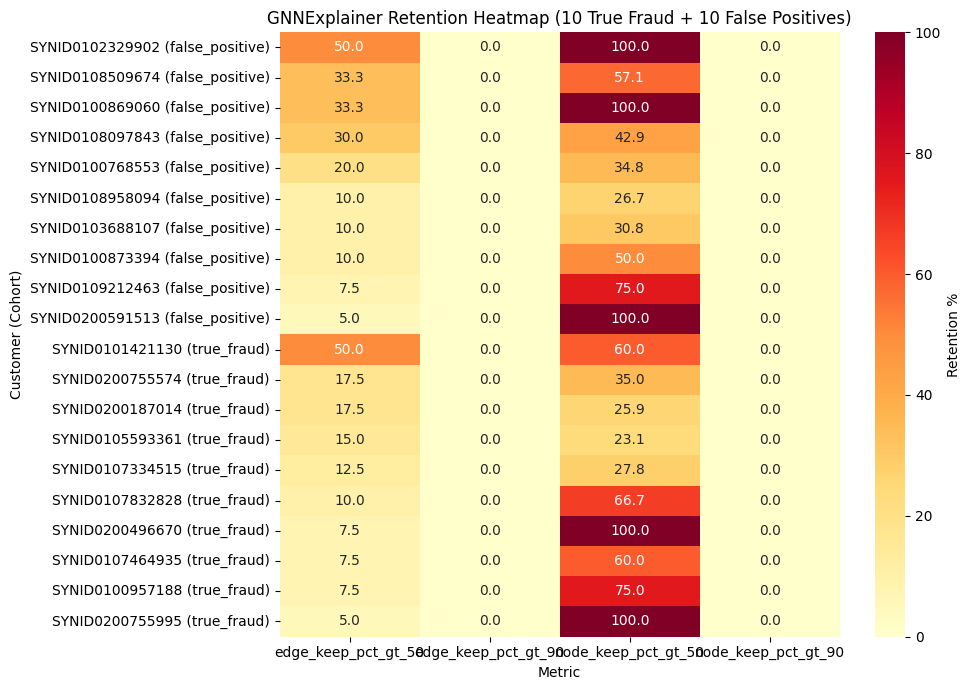

Saved: outputs/cohort_20_gnn_mask_heatmap.png

Cohort mean retention (%):
                edge_keep_pct_gt_50  edge_keep_pct_gt_90  node_keep_pct_gt_50  \
cohort_type                                                                     
false_positive                20.92                  0.0                61.72   
true_fraud                    15.00                  0.0                57.34   

                node_keep_pct_gt_90  
cohort_type                          
false_positive                  0.0  
true_fraud                      0.0  


In [11]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
import torch_geometric.transforms as T
from torch_geometric.explain import Explainer, GNNExplainer
from lib.model_utils import load_sage_model

np.random.seed(42)
torch.manual_seed(42)

# ------------------------------------------------------------------
# A) Build cohort: 10 true fraud + 10 false positives
# ------------------------------------------------------------------
rank_candidates = [
    'outputs/rank_df_with_anchor_expansion.csv.gz',
    'outputs/rank_df_with_semi_supervision.csv.gz',
    'outputs/lgbm_ranking_features.csv.gz',
]
rank_path = next((p for p in rank_candidates if os.path.exists(p)), None)
if rank_path is None:
    raise FileNotFoundError('No ranking artifact found for cohort run.')

rank_df = pd.read_csv(rank_path).copy()
if 'customer_id' not in rank_df.columns or 'true_label' not in rank_df.columns:
    raise KeyError('Ranking artifact must include customer_id and true_label for cohort selection.')

rank_df['customer_id'] = rank_df['customer_id'].astype(str).str.strip()
rank_df['true_label'] = pd.to_numeric(rank_df['true_label'], errors='coerce')

score_candidates = [
    'scarcity_anchor_ensemble_prob',
    'scarcity_semi_ensemble_prob',
    'scarcity_ensemble_prob',
    'lgb_fraud_prob',
    'mlp_fraud_prob',
    'combined_model_score',
    'review_priority_score',
]
score_col = next((c for c in score_candidates if c in rank_df.columns), None)
if score_col is None:
    raise KeyError('No usable fraud score column found.')
rank_df[score_col] = pd.to_numeric(rank_df[score_col], errors='coerce').fillna(0.0)

pred_col_candidates = ['predicted_label', 'lgb_label', 'final_train_label']
pred_col = next((c for c in pred_col_candidates if c in rank_df.columns), None)

# True fraud: labeled as fraud (true_label == 1), top scoring
true_fraud = (
    rank_df[rank_df['true_label'] == 1]
    .sort_values(score_col, ascending=False)
    .head(10)
    .copy()
)

# False positives: confirmed-legit customers (true_label == 0) with the highest fraud
# scores — the model ranked them as suspicious but they are actually known-good customers.
# Note: the binary lgb_label does not flag any confirmed-legit customer, so we select
# by ensemble score directly rather than requiring pred_fraud == 1.
false_pos = (
    rank_df[rank_df['true_label'] == 0]
    .sort_values(score_col, ascending=False)
    .head(10)
    .copy()
)

true_fraud['cohort_type'] = 'true_fraud'
false_pos['cohort_type'] = 'false_positive'
cohort_df = pd.concat([true_fraud, false_pos], ignore_index=True)

if len(cohort_df) == 0:
    raise ValueError('No cohort members found. Check label/prediction columns.')

if 'component' in cohort_df.columns and 'cluster_label' not in cohort_df.columns and os.path.exists('outputs/cluster_interpretations_real.csv'):
    cl = pd.read_csv('outputs/cluster_interpretations_real.csv')
    if {'component_id', 'cluster_label'}.issubset(cl.columns):
        cohort_df = cohort_df.merge(
            cl[['component_id', 'cluster_label']].rename(columns={'component_id': 'component'}),
            on='component',
            how='left',
        )

cohort_df.to_csv('outputs/cohort_20_customer_selection.csv', index=False)
print('Cohort selected from:', rank_path)
print('Score column:', score_col, '| Pred column:', pred_col if pred_col else 'derived')
print('True fraud selected:', len(true_fraud), '| False positives selected:', len(false_pos))
print(f'  → FP = confirmed-legit (true_label=0) with highest {score_col}')
print('Saved: outputs/cohort_20_customer_selection.csv')

# ------------------------------------------------------------------
# B) Run explanation pipeline for the 20-customer cohort
# ------------------------------------------------------------------
txn_path = 'outputs/scotiabank_transactions.csv.gz'
if not os.path.exists(txn_path):
    txn_path = 'outputs/master_transaction_pool.csv.gz'
if not os.path.exists(txn_path):
    raise FileNotFoundError('No transaction history file found.')

tx = pd.read_csv(txn_path, low_memory=False)
tx['customer_id'] = tx['customer_id'].astype(str).str.strip()
if 'transaction_datetime' in tx.columns:
    tx['transaction_datetime'] = pd.to_datetime(tx['transaction_datetime'], errors='coerce')
else:
    tx['transaction_datetime'] = pd.NaT
tx['amount_cad'] = pd.to_numeric(tx.get('amount_cad', 0.0), errors='coerce').fillna(0.0)

amt_p95 = float(tx['amount_cad'].quantile(0.95))
amt_p99 = float(tx['amount_cad'].quantile(0.99))

def detect_ollama_endpoint():
    endpoints = [
        'http://localhost:11434/api/generate',
        'http://132.145.111.57:11434/api/generate',
    ]
    for ep in endpoints:
        try:
            r = requests.get(ep.replace('/api/generate', '/api/tags'), timeout=3)
            if r.status_code == 200:
                return ep
        except Exception:
            pass
    return None

OLLAMA_ENDPOINT = detect_ollama_endpoint()
OLLAMA_MODEL = 'gemma2:2b'
USE_LLM = OLLAMA_ENDPOINT is not None

def tx_summary(customer_id):
    ct = tx.loc[tx['customer_id'] == customer_id].copy()
    if len(ct) == 0:
        return {
            'txn_count': 0,
            'mean_amount': 0.0,
            'std_amount': 0.0,
            'max_amount': 0.0,
            'latest_amount': 0.0,
            'latest_time': 'N/A',
            'high_value_count': 0,
            'night_ratio': 0.0,
            'cash_ratio': 0.0,
            'tipping_point': 'No history available.',
        }

    ct = ct.sort_values('transaction_datetime')
    valid_dt = ct['transaction_datetime'].notna()
    if valid_dt.any():
        hours = ct.loc[valid_dt, 'transaction_datetime'].dt.hour
        night_ratio = float(((hours <= 5) | (hours >= 23)).mean())
        latest_time = str(ct.loc[valid_dt, 'transaction_datetime'].iloc[-1])
    else:
        night_ratio = 0.0
        latest_time = 'N/A'

    ct2 = ct.copy()
    ct2['anom_score'] = (
        1.0 * (ct2['amount_cad'] >= amt_p99).astype(int)
        + 0.6 * ((ct2['transaction_datetime'].dt.hour <= 5) | (ct2['transaction_datetime'].dt.hour >= 23)).fillna(False).astype(int)
        + 0.4 * (ct2['amount_cad'] >= amt_p95).astype(int)
    )
    tipping = 'No clear tipping point detected.'
    if len(ct2) >= 12 and ct2['transaction_datetime'].notna().sum() >= 12:
        t = ct2.loc[ct2['transaction_datetime'].notna(), ['transaction_datetime', 'anom_score']].sort_values('transaction_datetime')
        t['roll_mean_6'] = t['anom_score'].rolling(6, min_periods=6).mean()
        base = float(t['roll_mean_6'].dropna().head(max(1, len(t)//3)).mean()) if t['roll_mean_6'].notna().any() else 0.0
        trig = t[t['roll_mean_6'] >= base + 0.8]
        if len(trig) > 0:
            tipping = f"Shift begins around {trig.iloc[0]['transaction_datetime']}."

    latest = ct.iloc[-1]
    return {
        'txn_count': int(len(ct)),
        'mean_amount': float(ct['amount_cad'].mean()),
        'std_amount': float(ct['amount_cad'].std(ddof=0)),
        'max_amount': float(ct['amount_cad'].max()),
        'latest_amount': float(latest['amount_cad']),
        'latest_time': latest_time,
        'high_value_count': int((ct['amount_cad'] >= amt_p99).sum()),
        'night_ratio': night_ratio,
        'cash_ratio': float(pd.to_numeric(ct.get('cash_indicator', 0), errors='coerce').fillna(0).mean()),
        'tipping_point': tipping,
    }

def llm_explain(row, s):
    prompt = f"""You are writing a fraud-investigation note for one customer.
Write exactly 3 sentences and start sentence 1 with: This customer was deemed suspicious because
Do not use the word also.
Use context, not raw metric dumping.

Customer ID: {row['customer_id']}
Cohort: {row['cohort_type']}
Model score ({score_col}): {float(row.get(score_col, 0.0)):.4f}
True label: {row.get('true_label', 'N/A')}
Cluster label: {row.get('cluster_label', 'N/A')}

Transaction summary:
- txn_count={s['txn_count']} mean={s['mean_amount']:.2f} std={s['std_amount']:.2f} max={s['max_amount']:.2f}
- latest={s['latest_amount']:.2f} at {s['latest_time']}
- p99_count={s['high_value_count']} night_ratio={s['night_ratio']:.2%} cash_ratio={s['cash_ratio']:.2%}
- tipping_point={s['tipping_point']}

Include:
1) strongest behavioral irregularity
2) whether/when tipping point occurs
3) concise model-context interpretation
"""
    payload = {
        'model': OLLAMA_MODEL,
        'prompt': prompt,
        'stream': False,
        'temperature': 0.1,
        'num_predict': 200,
    }
    try:
        r = requests.post(OLLAMA_ENDPOINT, json=payload, timeout=45)
        if r.status_code == 200:
            txt = r.json().get('response', '').replace('\n', ' ').strip()
            if txt:
                return txt[:1200]
    except Exception:
        pass
    return None

def template_explain(row, s):
    reason = 'an abrupt randomness shift in transaction behavior'
    if s['high_value_count'] > 0:
        reason = 'repeated extreme-value transactions relative to the portfolio'
    elif s['night_ratio'] >= 0.30:
        reason = 'concentrated late-night activity'
    return (
        f"This customer was deemed suspicious because their history shows {reason} with risk concentration around key events. "
        f"The estimated tipping point is: {s['tipping_point']} "
        f"Model context remains consistent with fraud-oriented graph/anomaly signals for this cohort position."
    )

exp_rows = []
for _, r in cohort_df.iterrows():
    cid = str(r['customer_id']).strip()
    s = tx_summary(cid)
    txt = llm_explain(r, s) if USE_LLM else None
    src = 'llm' if txt else 'template'
    if not txt:
        txt = template_explain(r, s)

    out = r.to_dict()
    out.update(s)
    out['customer_explanation'] = txt
    out['explanation_source'] = src
    exp_rows.append(out)

cohort_exp_df = pd.DataFrame(exp_rows)
cohort_exp_df.to_csv('outputs/cohort_20_explanations.csv', index=False)
print('LLM endpoint available:', USE_LLM)
if USE_LLM:
    print('Using endpoint:', OLLAMA_ENDPOINT)
print('Saved: outputs/cohort_20_explanations.csv')

# ------------------------------------------------------------------
# C) GNNExplainer retention + heatmap on original model with NeighborLoader
# ------------------------------------------------------------------
with open('outputs/sage_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

needed = ['x_cust', 'x_cat', 'x_city', 'edge_cust_cat', 'edge_cust_city', 'cust_map']
miss = [k for k in needed if k not in art]
if miss:
    raise KeyError(f'Missing artifact keys: {miss}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('GNNExplainer device:', device)

data_orig = HeteroData()
data_orig['customer'].x = art['x_cust']
data_orig['category'].x = art['x_cat']
data_orig['city'].x = art['x_city']
data_orig['customer', 'purchases_at', 'category'].edge_index = art['edge_cust_cat']
data_orig['customer', 'transacts_in', 'city'].edge_index = art['edge_cust_city']
data_orig = T.ToUndirected()(data_orig)

cust_map = art['cust_map']
model = load_sage_model('outputs/fraud_sage_model.pth', artifacts=art)
if model is None:
    raise RuntimeError('Could not load FraudSAGE model.')
model = model.to(device).eval()

num_neighbors = [20, 15, 10]
gnn_rows = []
for _, r in cohort_df.iterrows():
    cid = str(r['customer_id']).strip()
    if cid not in cust_map:
        continue

    global_idx = int(cust_map[cid])
    seed_mask = torch.zeros(data_orig['customer'].num_nodes, dtype=torch.bool)
    seed_mask[global_idx] = True

    loader = NeighborLoader(
        data_orig,
        num_neighbors=num_neighbors,
        input_nodes=('customer', seed_mask),
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )
    sub = next(iter(loader)).to(device)

    n_id = sub['customer'].n_id
    hit = (n_id == global_idx).nonzero(as_tuple=False).view(-1)
    if hit.numel() == 0:
        continue
    local_idx = int(hit[0].item())

    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=20),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='binary_classification', task_level='node', return_type='raw'),
    )
    exp = explainer(sub.x_dict, sub.edge_index_dict, index=local_idx)
    edge_mask_dict = exp.edge_mask_dict

    total_edges = 0
    e50 = 0
    e90 = 0
    n_all = set()
    n50 = set()
    n90 = set()

    for et, ei_t in sub.edge_index_dict.items():
        st, _, dt = et
        if st != 'customer' and dt != 'customer':
            continue

        ei = ei_t.detach().cpu().numpy()
        mask = edge_mask_dict[et].detach().cpu().numpy() if et in edge_mask_dict else np.zeros(ei.shape[1], dtype=float)

        if st == 'customer':
            inc = np.where(ei[0] == local_idx)[0]
            nbr_type = dt
            nbr_ids = ei[1, inc] if len(inc) > 0 else np.array([], dtype=int)
        else:
            inc = np.where(ei[1] == local_idx)[0]
            nbr_type = st
            nbr_ids = ei[0, inc] if len(inc) > 0 else np.array([], dtype=int)

        if len(inc) == 0:
            continue

        rs = mask[inc]
        total_edges += int(len(inc))
        e50 += int((rs > 0.50).sum())
        e90 += int((rs > 0.90).sum())

        for j, nb in enumerate(nbr_ids):
            key = (nbr_type, int(nb))
            n_all.add(key)
            if rs[j] > 0.50:
                n50.add(key)
            if rs[j] > 0.90:
                n90.add(key)

    gnn_rows.append({
        'customer_id': cid,
        'cohort_type': r['cohort_type'],
        'orig_nearby_edges': total_edges,
        'edges_rel_gt_50': e50,
        'edges_rel_gt_90': e90,
        'orig_nearby_nodes': len(n_all),
        'nodes_rel_gt_50': len(n50),
        'nodes_rel_gt_90': len(n90),
        'edge_keep_pct_gt_50': 100.0 * e50 / max(1, total_edges),
        'edge_keep_pct_gt_90': 100.0 * e90 / max(1, total_edges),
        'node_keep_pct_gt_50': 100.0 * len(n50) / max(1, len(n_all)),
        'node_keep_pct_gt_90': 100.0 * len(n90) / max(1, len(n_all)),
    })

gnn_df = pd.DataFrame(gnn_rows)
gnn_df.to_csv('outputs/cohort_20_gnn_mask_metrics.csv', index=False)
print('Saved: outputs/cohort_20_gnn_mask_metrics.csv')

if len(gnn_df) > 0:
    heat_cols = ['edge_keep_pct_gt_50', 'edge_keep_pct_gt_90', 'node_keep_pct_gt_50', 'node_keep_pct_gt_90']
    plot_df = gnn_df[['customer_id', 'cohort_type'] + heat_cols].copy()
    plot_df['row_label'] = plot_df['customer_id'] + ' (' + plot_df['cohort_type'] + ')'
    plot_df = plot_df.sort_values(['cohort_type', 'edge_keep_pct_gt_50'], ascending=[True, False])

    plt.figure(figsize=(10, max(6, 0.35 * len(plot_df))))
    sns.heatmap(
        plot_df.set_index('row_label')[heat_cols],
        cmap='YlOrRd',
        annot=True,
        fmt='.1f',
        cbar_kws={'label': 'Retention %'},
    )
    plt.title('GNNExplainer Retention Heatmap (10 True Fraud + 10 False Positives)')
    plt.xlabel('Metric')
    plt.ylabel('Customer (Cohort)')
    plt.tight_layout()
    plt.savefig('outputs/cohort_20_gnn_mask_heatmap.png', dpi=160)
    plt.show()
    print('Saved: outputs/cohort_20_gnn_mask_heatmap.png')

    cohort_summary = gnn_df.groupby('cohort_type')[heat_cols].mean().round(2)
    print('\nCohort mean retention (%):')
    print(cohort_summary)
else:
    print('No GNN rows generated (check cust_map overlap).')


## Manual Analyst Review Dashboard (Top Unlabeled Candidates)

This section builds a standalone HTML page for manual triage and labeling of top-ranked unlabeled customers.

Features:
- Candidate list with search, score threshold, and sorting
- Per-customer profile summary and model/cluster context
- Associated nodes context (top merchant categories and cities)
- Transaction history table and amount timeline
- In-browser labeling (`fraud`, `legit`, `unsure`, `needs_more_data`) with confidence + notes
- Export labels to CSV for retraining pipelines


In [14]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------------
# Build a standalone HTML reviewer for top flagged unlabeled customers
# ------------------------------------------------------------------
TOP_N = 250
TXN_PER_CUSTOMER_CAP = 300

rank_candidates = [
    'outputs/rank_df_with_anchor_expansion.csv.gz',
    'outputs/rank_df_with_semi_supervision.csv.gz',
    'outputs/lgbm_ranking_features.csv.gz',
]
rank_path = next((p for p in rank_candidates if os.path.exists(p)), None)
if rank_path is None:
    raise FileNotFoundError('No ranking artifact found. Expected one of the rank_df outputs.')

rank_df = pd.read_csv(rank_path)
if 'customer_id' not in rank_df.columns:
    raise KeyError('Ranking artifact must include customer_id.')

rank_df['customer_id'] = rank_df['customer_id'].astype(str).str.strip()
if 'true_label' in rank_df.columns:
    rank_df['true_label'] = pd.to_numeric(rank_df['true_label'], errors='coerce')
    unlabeled_mask = ~rank_df['true_label'].isin([0, 1])
else:
    unlabeled_mask = pd.Series(True, index=rank_df.index)

score_priority = [
    'scarcity_anchor_ensemble_prob',
    'scarcity_semi_ensemble_prob',
    'scarcity_ensemble_prob',
    'suspicion_evidence_score_v3_tuned',
    'suspicion_evidence_score_v3',
    'suspicion_evidence_score_v2',
    'suspicion_evidence_score',
    'lgb_fraud_prob',
    'mlp_fraud_prob',
]
score_col = next((c for c in score_priority if c in rank_df.columns), None)
if score_col is None:
    raise KeyError('No score column found in ranking artifact.')

rank_df[score_col] = pd.to_numeric(rank_df[score_col], errors='coerce').fillna(0.0)
candidates = rank_df.loc[unlabeled_mask].copy()
candidates = candidates.sort_values(score_col, ascending=False).head(TOP_N).reset_index(drop=True)

if len(candidates) == 0:
    raise ValueError('No unlabeled candidates found in ranking artifact.')

# Load transactions
txn_candidates = ['outputs/scotiabank_transactions.csv.gz', 'outputs/master_transaction_pool.csv.gz']
txn_path = next((p for p in txn_candidates if os.path.exists(p)), None)
if txn_path is None:
    raise FileNotFoundError('No transaction history file found.')

tx = pd.read_csv(txn_path, low_memory=False)
if 'customer_id' not in tx.columns:
    raise KeyError('Transaction file must include customer_id.')

tx['customer_id'] = tx['customer_id'].astype(str).str.strip()
if 'transaction_datetime' in tx.columns:
    tx['transaction_datetime'] = pd.to_datetime(tx['transaction_datetime'], errors='coerce')
else:
    tx['transaction_datetime'] = pd.NaT

tx['amount_cad'] = pd.to_numeric(tx.get('amount_cad', 0.0), errors='coerce').fillna(0.0)
if 'cash_indicator' not in tx.columns:
    tx['cash_indicator'] = 0
if 'ecommerce_ind' not in tx.columns:
    tx['ecommerce_ind'] = 0
if 'merchant_category' not in tx.columns:
    tx['merchant_category'] = 'unknown'
if 'city' not in tx.columns:
    tx['city'] = 'unknown'

review_ids = set(candidates['customer_id'])
tx_sel = tx.loc[tx['customer_id'].isin(review_ids)].copy()

if len(tx_sel) == 0:
    raise ValueError('No transactions found for selected top unlabeled candidates.')

amt_p95 = float(tx_sel['amount_cad'].quantile(0.95)) if len(tx_sel) else 0.0

# Build compact customer review payload
rows = []
for _, r in candidates.iterrows():
    cid = str(r['customer_id']).strip()
    ct = tx_sel.loc[tx_sel['customer_id'] == cid].copy()
    ct = ct.sort_values('transaction_datetime').tail(TXN_PER_CUSTOMER_CAP)

    if len(ct) > 0:
        valid_dt = ct['transaction_datetime'].notna()
        if valid_dt.any():
            hrs = ct.loc[valid_dt, 'transaction_datetime'].dt.hour
            night_ratio = float(((hrs <= 5) | (hrs >= 23)).mean())
            first_ts = ct.loc[valid_dt, 'transaction_datetime'].iloc[0]
            last_ts = ct.loc[valid_dt, 'transaction_datetime'].iloc[-1]
            first_ts_s = first_ts.strftime('%Y-%m-%d %H:%M:%S')
            last_ts_s = last_ts.strftime('%Y-%m-%d %H:%M:%S')
        else:
            night_ratio = 0.0
            first_ts_s = 'N/A'
            last_ts_s = 'N/A'

        cash_ratio = float(pd.to_numeric(ct['cash_indicator'], errors='coerce').fillna(0).mean())
        ecom_ratio = float(pd.to_numeric(ct['ecommerce_ind'], errors='coerce').fillna(0).mean())

        top_categories = (
            ct['merchant_category'].astype(str).fillna('unknown').value_counts().head(8).index.tolist()
        )
        top_cities = (
            ct['city'].astype(str).fillna('unknown').value_counts().head(8).index.tolist()
        )

        txn_points = []
        for _, t in ct.iterrows():
            dt = t['transaction_datetime']
            dt_s = dt.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(dt) else ''
            txn_points.append({
                'dt': dt_s,
                'amount': float(t.get('amount_cad', 0.0)),
                'merchant_category': str(t.get('merchant_category', '')),
                'city': str(t.get('city', '')),
                'cash_indicator': int(np.nan_to_num(pd.to_numeric(t.get('cash_indicator', 0), errors='coerce'), nan=0.0)),
                'ecommerce_ind': int(np.nan_to_num(pd.to_numeric(t.get('ecommerce_ind', 0), errors='coerce'), nan=0.0)),
            })

        profile = {
            'txn_count': int(len(ct)),
            'mean_amount': float(ct['amount_cad'].mean()),
            'std_amount': float(ct['amount_cad'].std(ddof=0)),
            'max_amount': float(ct['amount_cad'].max()),
            'high_value_count': int((ct['amount_cad'] >= amt_p95).sum()),
            'night_ratio': night_ratio,
            'cash_ratio': cash_ratio,
            'ecom_ratio': ecom_ratio,
            'first_txn': first_ts_s,
            'last_txn': last_ts_s,
            'top_categories': top_categories,
            'top_cities': top_cities,
        }
    else:
        txn_points = []
        profile = {
            'txn_count': 0,
            'mean_amount': 0.0,
            'std_amount': 0.0,
            'max_amount': 0.0,
            'high_value_count': 0,
            'night_ratio': 0.0,
            'cash_ratio': 0.0,
            'ecom_ratio': 0.0,
            'first_txn': 'N/A',
            'last_txn': 'N/A',
            'top_categories': [],
            'top_cities': [],
        }

    # Keep all rank/model context fields for human inspection (excluding huge arrays)
    model_context = {}
    for col in candidates.columns:
        val = r[col]
        if pd.isna(val):
            model_context[col] = None
        elif isinstance(val, (np.integer, np.int64, np.int32)):
            model_context[col] = int(val)
        elif isinstance(val, (np.floating, np.float32, np.float64)):
            model_context[col] = float(val)
        else:
            model_context[col] = str(val)

    rows.append({
        'customer_id': cid,
        'primary_score_col': score_col,
        'primary_score': float(r.get(score_col, 0.0)),
        'profile': profile,
        'transactions': txn_points,
        'model_context': model_context,
    })

payload = {
    'generated_at': datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S UTC'),
    'rank_source': rank_path,
    'txn_source': txn_path,
    'score_col': score_col,
    'top_n': int(len(rows)),
    'customers': rows,
}

html_template = '''<!doctype html>
<html>
<head>
  <meta charset="utf-8" />
  <title>Manual Fraud Review Dashboard</title>
  <style>
    body { margin:0; font-family: Segoe UI, Arial, sans-serif; background:#f4f6f8; color:#1f2a37; }
    .topbar { background:#0f172a; color:#fff; padding:12px 16px; font-size:14px; display:flex; gap:16px; flex-wrap:wrap; }
    .layout { display:grid; grid-template-columns: 32% 68%; min-height: calc(100vh - 52px); }
    .left { border-right:1px solid #dbe3ea; background:#fff; display:flex; flex-direction:column; }
    .right { padding:12px; overflow:auto; }
    .controls { padding:10px; border-bottom:1px solid #e5e7eb; display:grid; grid-template-columns:1fr 1fr; gap:8px; }
    .controls input, .controls select, .controls button, textarea { width:100%; padding:8px; border:1px solid #cfd8e3; border-radius:6px; box-sizing:border-box; font-size:13px; }
    .list { overflow:auto; flex:1; }
    .row { border-bottom:1px solid #eef2f6; padding:10px; cursor:pointer; }
    .row:hover { background:#f8fafc; }
    .row.active { background:#e8f0ff; }
    .muted { color:#667085; font-size:12px; }
    .score { font-weight:600; color:#0b5fff; }
    .grid2 { display:grid; grid-template-columns:1fr 1fr; gap:10px; margin-bottom:10px; }
    .card { background:#fff; border:1px solid #e5e7eb; border-radius:8px; padding:10px; }
    .card h3 { margin:0 0 8px 0; font-size:14px; }
    .pill { display:inline-block; padding:2px 8px; border-radius:999px; font-size:11px; background:#eef4ff; color:#244fbd; margin-right:6px; margin-bottom:6px; }
    table { width:100%; border-collapse:collapse; background:#fff; }
    th, td { border-bottom:1px solid #edf2f7; padding:6px; font-size:12px; text-align:left; }
    th { background:#f8fafc; position:sticky; top:0; }
    #txnTableWrap { max-height:280px; overflow:auto; border:1px solid #e5e7eb; border-radius:8px; }
    .labelBox { display:grid; grid-template-columns:1fr 1fr; gap:8px; }
    .small { font-size:12px; }
    canvas { width:100%; height:170px; border:1px solid #e5e7eb; border-radius:8px; background:#fff; }
    pre { background:#0b1220; color:#e5e7eb; padding:10px; border-radius:8px; font-size:11px; max-height:240px; overflow:auto; }
  </style>
</head>
<body>
  <div class="topbar">
    <div><b>Manual Fraud Review Dashboard</b></div>
    <div id="meta"></div>
    <div id="labelStats"></div>
  </div>
  <div class="layout">
    <div class="left">
      <div class="controls">
        <input id="search" placeholder="Search customer_id" />
        <input id="minScore" type="number" step="0.0001" placeholder="Min score" />
        <select id="sortBy">
          <option value="score_desc">Sort: score desc</option>
          <option value="score_asc">Sort: score asc</option>
          <option value="txn_desc">Sort: txn count desc</option>
          <option value="txn_asc">Sort: txn count asc</option>
        </select>
        <button id="clearFilters">Clear filters</button>
      </div>
      <div class="controls" style="grid-template-columns:1fr 1fr 1fr;">
        <button id="prevBtn">Prev</button>
        <button id="nextBtn">Next</button>
        <button id="exportBtn">Export labels CSV</button>
      </div>
      <div class="list" id="list"></div>
    </div>
    <div class="right">
      <div class="grid2">
        <div class="card">
          <h3>Customer Overview</h3>
          <div id="overview"></div>
        </div>
        <div class="card">
          <h3>Associated Nodes Context</h3>
          <div class="small"><b>Top merchant_category nodes</b></div>
          <div id="cats"></div>
          <div class="small" style="margin-top:8px;"><b>Top city nodes</b></div>
          <div id="cities"></div>
        </div>
      </div>

      <div class="grid2">
        <div class="card">
          <h3>Manual Labeling</h3>
          <div class="labelBox">
            <select id="labelSel">
              <option value="">Select label...</option>
              <option value="fraud">fraud</option>
              <option value="legit">legit</option>
              <option value="unsure">unsure</option>
              <option value="needs_more_data">needs_more_data</option>
            </select>
            <select id="confSel">
              <option value="">Confidence...</option>
              <option value="1">1</option>
              <option value="2">2</option>
              <option value="3">3</option>
              <option value="4">4</option>
              <option value="5">5</option>
            </select>
          </div>
          <textarea id="notes" rows="3" placeholder="Reviewer notes..."></textarea>
          <div class="labelBox" style="margin-top:8px;">
            <button id="saveLabelBtn">Save label</button>
            <button id="clearLabelBtn">Clear label</button>
          </div>
          <div class="small muted" style="margin-top:8px;">Labels are saved in browser local storage and exported as CSV.</div>
        </div>
        <div class="card">
          <h3>Transaction Amount Timeline</h3>
          <canvas id="timeline" width="900" height="180"></canvas>
        </div>
      </div>

      <div class="card" style="margin-bottom:10px;">
        <h3>Transaction History</h3>
        <div id="txnTableWrap">
          <table>
            <thead>
              <tr>
                <th>datetime</th><th>amount_cad</th><th>merchant_category</th><th>city</th><th>cash</th><th>ecom</th>
              </tr>
            </thead>
            <tbody id="txnBody"></tbody>
          </table>
        </div>
      </div>

      <div class="card">
        <h3>Full Model / Profile Context</h3>
        <pre id="raw"></pre>
      </div>
    </div>
  </div>

<script>
const DATA = __DATA_JSON__;
const LS_KEY = 'manual_fraud_review_labels_v1';
let labels = {};
try {
  labels = JSON.parse(localStorage.getItem(LS_KEY) || '{}');
  if (!labels || typeof labels !== 'object') labels = {};
} catch (e) {
  labels = {};
  localStorage.removeItem(LS_KEY);
}
let filtered = [...DATA.customers];
let selectedIdx = 0;

function fmt(v, d=4){
  if (v === null || v === undefined || Number.isNaN(v)) return '';
  if (typeof v === 'number') return v.toFixed(d);
  return String(v);
}

function loadLabel(cid){
  const x = labels[cid] || {};
  document.getElementById('labelSel').value = x.label || '';
  document.getElementById('confSel').value = x.confidence || '';
  document.getElementById('notes').value = x.notes || '';
}

function labelStats(){
  const vals = Object.values(labels);
  const done = vals.filter(v => v.label).length;
  document.getElementById('labelStats').textContent = `Labeled: ${done}/${DATA.customers.length}`;
}

function saveLabels(){
  localStorage.setItem(LS_KEY, JSON.stringify(labels));
  labelStats();
  renderList();
}

function applyFilters(){
  const q = document.getElementById('search').value.toLowerCase().trim();
  const minScoreRaw = document.getElementById('minScore').value;
  const minScore = minScoreRaw === '' ? -Infinity : Number(minScoreRaw);
  const sortBy = document.getElementById('sortBy').value;

  filtered = DATA.customers.filter(c => {
    const okQ = c.customer_id.toLowerCase().includes(q);
    const okS = Number(c.primary_score) >= minScore;
    return okQ && okS;
  });

  if (sortBy === 'score_desc') filtered.sort((a,b)=>b.primary_score-a.primary_score);
  if (sortBy === 'score_asc') filtered.sort((a,b)=>a.primary_score-b.primary_score);
  if (sortBy === 'txn_desc') filtered.sort((a,b)=>(b.profile.txn_count||0)-(a.profile.txn_count||0));
  if (sortBy === 'txn_asc') filtered.sort((a,b)=>(a.profile.txn_count||0)-(b.profile.txn_count||0));

  if (selectedIdx >= filtered.length) selectedIdx = Math.max(0, filtered.length - 1);
  renderList();
  renderDetail();
}

function renderList(){
  const list = document.getElementById('list');
  list.innerHTML = '';
  filtered.forEach((c, i) => {
    const div = document.createElement('div');
    div.className = 'row' + (i === selectedIdx ? ' active' : '');
    const lab = labels[c.customer_id]?.label || '';
    const conf = labels[c.customer_id]?.confidence || '';
    div.innerHTML = `
      <div><b>${c.customer_id}</b></div>
      <div class="muted">${c.primary_score_col}: <span class="score">${fmt(c.primary_score, 5)}</span> | txns: ${c.profile.txn_count}</div>
      <div class="muted">component: ${c.model_context.component ?? ''} | hdb: ${c.model_context.hdb_component ?? ''}</div>
      <div class="muted">label: ${lab || 'unlabeled'} ${conf ? `(conf ${conf})` : ''}</div>
    `;
    div.onclick = () => { selectedIdx = i; renderList(); renderDetail(); };
    list.appendChild(div);
  });
}

function drawTimeline(points){
  const canvas = document.getElementById('timeline');
  const ctx = canvas.getContext('2d');
  const w = canvas.width, h = canvas.height;
  ctx.clearRect(0, 0, w, h);

  ctx.fillStyle = '#ffffff';
  ctx.fillRect(0,0,w,h);
  ctx.strokeStyle = '#d1d9e0';
  ctx.strokeRect(0,0,w,h);

  if (!points || points.length === 0){
    ctx.fillStyle = '#64748b';
    ctx.fillText('No transaction points available', 12, 24);
    return;
  }

  const amounts = points.map(p => Number(p.amount) || 0);
  const minV = Math.min(...amounts);
  const maxV = Math.max(...amounts);
  const pad = 25;
  const xStep = (w - 2*pad) / Math.max(points.length - 1, 1);

  function y(v){
    if (maxV === minV) return h/2;
    return h - pad - ((v - minV) / (maxV - minV)) * (h - 2*pad);
  }

  ctx.strokeStyle = '#2563eb';
  ctx.lineWidth = 2;
  ctx.beginPath();
  points.forEach((p, i) => {
    const xx = pad + i * xStep;
    const yy = y(Number(p.amount) || 0);
    if (i === 0) ctx.moveTo(xx, yy); else ctx.lineTo(xx, yy);
  });
  ctx.stroke();

  ctx.fillStyle = '#0f172a';
  ctx.font = '11px Segoe UI';
  ctx.fillText(`min: ${minV.toFixed(2)}`, 8, h-8);
  ctx.fillText(`max: ${maxV.toFixed(2)}`, 8, 14);
}

function renderDetail(){
  if (filtered.length === 0){
    document.getElementById('overview').innerHTML = 'No customers match filters.';
    document.getElementById('cats').innerHTML = '';
    document.getElementById('cities').innerHTML = '';
    document.getElementById('txnBody').innerHTML = '';
    document.getElementById('raw').textContent = '';
    return;
  }

  const c = filtered[selectedIdx];
  const p = c.profile || {};

  document.getElementById('overview').innerHTML = `
    <div><b>customer_id:</b> ${c.customer_id}</div>
    <div><b>${c.primary_score_col}:</b> ${fmt(c.primary_score, 6)}</div>
    <div><b>txn_count:</b> ${p.txn_count || 0}</div>
    <div><b>mean/std/max amount:</b> ${fmt(p.mean_amount,2)} / ${fmt(p.std_amount,2)} / ${fmt(p.max_amount,2)}</div>
    <div><b>night_ratio:</b> ${fmt((p.night_ratio||0)*100,2)}% | <b>cash_ratio:</b> ${fmt((p.cash_ratio||0)*100,2)}% | <b>ecom_ratio:</b> ${fmt((p.ecom_ratio||0)*100,2)}%</div>
    <div><b>high_value_count:</b> ${p.high_value_count || 0}</div>
    <div><b>first_txn:</b> ${p.first_txn || ''}</div>
    <div><b>last_txn:</b> ${p.last_txn || ''}</div>
  `;

  const cats = (p.top_categories || []).map(x => `<span class="pill">${x}</span>`).join('');
  const cities = (p.top_cities || []).map(x => `<span class="pill">${x}</span>`).join('');
  document.getElementById('cats').innerHTML = cats || '<span class="muted">None</span>';
  document.getElementById('cities').innerHTML = cities || '<span class="muted">None</span>';

  const txRows = (c.transactions || []).slice().reverse().map(t => `
    <tr>
      <td>${t.dt || ''}</td>
      <td>${fmt(Number(t.amount || 0),2)}</td>
      <td>${t.merchant_category || ''}</td>
      <td>${t.city || ''}</td>
      <td>${t.cash_indicator ?? ''}</td>
      <td>${t.ecommerce_ind ?? ''}</td>
    </tr>
  `).join('');
  document.getElementById('txnBody').innerHTML = txRows;

  drawTimeline(c.transactions || []);

  const rawObj = {
    customer_id: c.customer_id,
    primary_score_col: c.primary_score_col,
    primary_score: c.primary_score,
    profile: c.profile,
    model_context: c.model_context,
    current_manual_label: labels[c.customer_id] || null
  };
  document.getElementById('raw').textContent = JSON.stringify(rawObj, null, 2);

  loadLabel(c.customer_id);
}

function exportCSV(){
  const keys = ['customer_id','label','confidence','notes','reviewed_at'];
  const lines = [keys.join(',')];
  for (const c of DATA.customers){
    const cid = c.customer_id;
    const x = labels[cid] || {};
    const row = {
      customer_id: cid,
      label: x.label || '',
      confidence: x.confidence || '',
      notes: x.notes || '',
      reviewed_at: x.reviewed_at || ''
    };
    const esc = v => `"${String(v ?? '').replaceAll('"', '""')}"`;
    lines.push(keys.map(k => esc(row[k])).join(','));
  }
  const blob = new Blob([lines.join('\n')], {type:'text/csv;charset=utf-8;'});
  const a = document.createElement('a');
  a.href = URL.createObjectURL(blob);
  a.download = 'manual_review_labels.csv';
  a.click();
}

document.getElementById('saveLabelBtn').onclick = () => {
  if (filtered.length === 0) return;
  const c = filtered[selectedIdx];
  labels[c.customer_id] = {
    label: document.getElementById('labelSel').value,
    confidence: document.getElementById('confSel').value,
    notes: document.getElementById('notes').value,
    reviewed_at: new Date().toISOString()
  };
  saveLabels();
  renderDetail();
};

document.getElementById('clearLabelBtn').onclick = () => {
  if (filtered.length === 0) return;
  const c = filtered[selectedIdx];
  delete labels[c.customer_id];
  saveLabels();
  renderDetail();
};

document.getElementById('exportBtn').onclick = exportCSV;
document.getElementById('prevBtn').onclick = () => {
  if (filtered.length === 0) return;
  selectedIdx = Math.max(0, selectedIdx - 1);
  renderList(); renderDetail();
};
document.getElementById('nextBtn').onclick = () => {
  if (filtered.length === 0) return;
  selectedIdx = Math.min(filtered.length - 1, selectedIdx + 1);
  renderList(); renderDetail();
};

['search','minScore','sortBy'].forEach(id => {
  document.getElementById(id).addEventListener('input', applyFilters);
  document.getElementById(id).addEventListener('change', applyFilters);
});

document.getElementById('clearFilters').onclick = () => {
  document.getElementById('search').value = '';
  document.getElementById('minScore').value = '';
  document.getElementById('sortBy').value = 'score_desc';
  applyFilters();
};

document.getElementById('meta').textContent =
  `Generated: ${DATA.generated_at} | Rank: ${DATA.rank_source} | Txn: ${DATA.txn_source} | Score: ${DATA.score_col} | Candidates: ${DATA.top_n}`;

labelStats();
applyFilters();
</script>
</body>
</html>
'''

html = html_template.replace('__DATA_JSON__', json.dumps(payload))
out_path = 'outputs/manual_unlabeled_review.html'
with open(out_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f'Wrote: {out_path}')
print('Open in browser and start labeling. Use "Export labels CSV" to save annotations.')


Wrote: outputs/manual_unlabeled_review.html
Open in browser and start labeling. Use "Export labels CSV" to save annotations.
